# 🔧 QoS Data Preparation Pipeline
### KNN Imputer + RobustScaler
---

# Data Preparation

## 📦 1. Installation des dépendances

In [1]:
!pip install scikit-learn joblib -q
print('✅ Dépendances installées')

✅ Dépendances installées


## 📁 2. Upload du fichier CSV

In [2]:
import pandas as pd
import requests
from io import StringIO

_df_loaded = False
try:
    file_id = '1H3__N0mCX9OdI_xWqRp3trgx-9OUPmjn'
    url = f'https://drive.google.com/uc?export=download&id={file_id}'
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text), sep=';')
    _df_loaded = True
    print(f'✅ Fichier chargé depuis Google Drive')
    print(f'📊 Shape : {df.shape}')
except Exception as _e:
    print(f'⚠️  Chargement Google Drive échoué : {_e}')
    print('   Création d\'un DataFrame vide — les cellules de préparation seront ignorées.')
    df = pd.DataFrame()
    _df_loaded = False

✅ Fichier chargé depuis Google Drive
📊 Shape : (2408, 55)


## 📚 3. Imports

## 📚 Cellule 2 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

print("✅ Imports OK")


✅ Imports OK


## 📁 Cellule 3 — Chargement des données

In [4]:
import pandas as pd, requests, os
from io import StringIO

_df_loaded = False

# ── Essai 1 : chargement local ──────────────────────────────
LOCAL_PATHS = [
    os.path.join(os.path.dirname(os.path.abspath("__file__")), "dso5_valise.csv"),
    r"C:/Users/ayoub/dso5_valise.csv",
    r"C:/Users/ayoub/dso5_actions.csv",
]
# Priorité : fichier Google Drive (jeu d'entraînement QoS)
try:
    file_id = "1H3__N0mCX9OdI_xWqRp3trgx-9OUPmjn"
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text), sep=";")
    _df_loaded = True
    print(f"✅ Fichier QoS chargé depuis Google Drive  — {df.shape[0]} lignes × {df.shape[1]} colonnes")
except Exception as _e:
    print(f"⚠️  Google Drive : {_e}")
    # Fallback : fichier valise local
    for p in LOCAL_PATHS:
        if os.path.exists(p):
            df = pd.read_csv(p)
            _df_loaded = True
            print(f"✅ Fichier local chargé : {p}  — {df.shape[0]} lignes × {df.shape[1]} colonnes")
            break
    if not _df_loaded:
        print("❌ Aucun fichier trouvé — data prep ignorée.")
        df = pd.DataFrame()


✅ Fichier QoS chargé depuis Google Drive  — 2408 lignes × 55 colonnes


## 📊 Cellule 4 — Analyse exploratoire (EDA)

══════════════════════════════════════════════════════════
              ANALYSE EXPLORATOIRE DES DONNÉES            
══════════════════════════════════════════════════════════
  Lignes             :    2,408
  Colonnes           :       55
  Numériques         :       53
  Catégorielles      :        2
  Valeurs manquantes :      617
  Doublons           :        0
──────────────────────────────────────────────────────────
  Features à forte asymétrie (|skew|>1) : 30
  Top 5 skewness :
    hop_1                               skew = +40.923
    peak_offpeak_indicator              skew = +28.296
    hop_4                               skew = +24.481
    hour                                skew = +21.887
    hops_min                            skew = +19.887
──────────────────────────────────────────────────────────


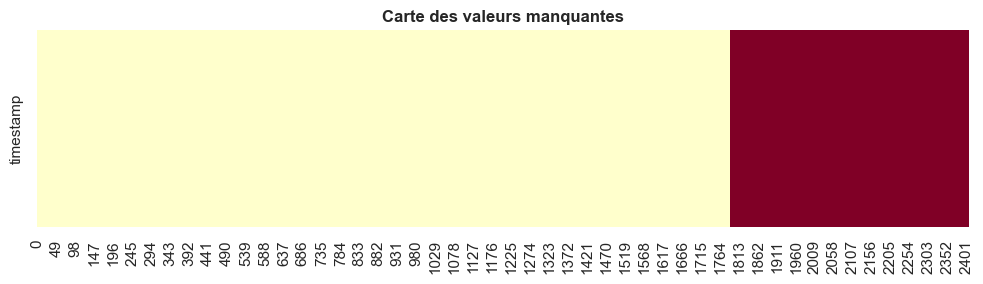

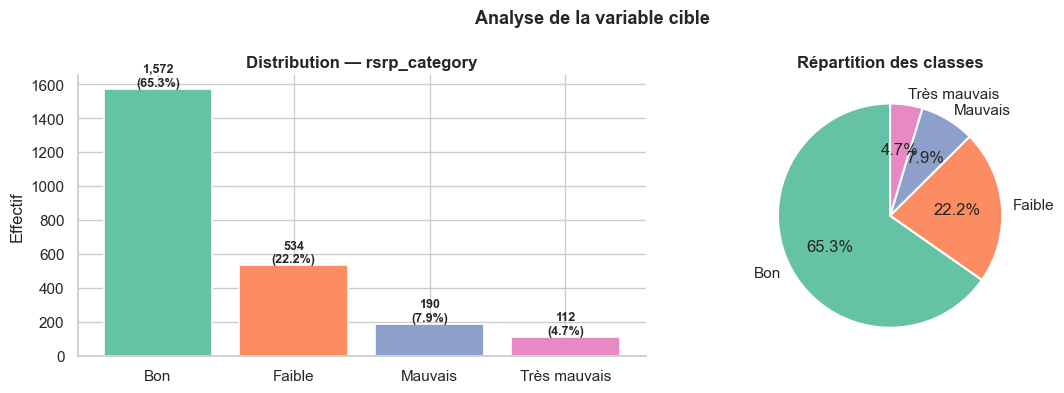

In [5]:
if not globals().get("_df_loaded") or df.empty:
    print("⏭️  EDA ignoré")
else:
    W = 58
    print("═"*W)
    print("  ANALYSE EXPLORATOIRE DES DONNÉES".center(W))
    print("═"*W)
    print(f"  Lignes             : {df.shape[0]:>8,}")
    print(f"  Colonnes           : {df.shape[1]:>8}")
    print(f"  Numériques         : {df.select_dtypes(include='number').shape[1]:>8}")
    print(f"  Catégorielles      : {df.select_dtypes(include='object').shape[1]:>8}")
    print(f"  Valeurs manquantes : {df.isnull().sum().sum():>8,}")
    print(f"  Doublons           : {df.duplicated().sum():>8,}")
    print("─"*W)

    num_cols = df.select_dtypes(include="number").columns.tolist()

    # ── Skewness des features numériques ─────────────────────
    skews = df[num_cols].skew().sort_values(ascending=False)
    high_skew = skews[skews.abs() > 1].index.tolist()
    print(f"  Features à forte asymétrie (|skew|>1) : {len(high_skew)}")
    print(f"  Top 5 skewness :")
    for col, v in skews.head(5).items():
        print(f"    {col:<35} skew = {v:+.3f}")
    print("─"*W)

    # ── Heatmap valeurs manquantes ────────────────────────────
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        fig, ax = plt.subplots(figsize=(10, 3))
        sns.heatmap(df[miss.index].isnull().T, cbar=False, yticklabels=True,
                    cmap="YlOrRd", ax=ax)
        ax.set_title("Carte des valeurs manquantes", fontweight="bold")
        plt.tight_layout(); plt.show()
    else:
        print("  ✅ Aucune valeur manquante")

    # ── Distribution de la target ─────────────────────────────
    target_candidates = ["rsrp_category","rsrp_category_label","rsrp_cat","category","y","label"]
    target_col = next((c for c in target_candidates if c in df.columns), None)
    if target_col:
        vc = df[target_col].value_counts()
        colors = sns.color_palette("Set2", len(vc))
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].bar(vc.index, vc.values, color=colors, edgecolor="white", linewidth=1.2)
        for i, (lbl, cnt) in enumerate(vc.items()):
            axes[0].text(i, cnt + vc.max()*0.01, f"{cnt:,}\n({cnt/len(df)*100:.1f}%)",
                         ha="center", fontsize=9, fontweight="bold")
        axes[0].set_title(f"Distribution — {target_col}", fontweight="bold")
        axes[0].set_xlabel(""); axes[0].set_ylabel("Effectif")
        axes[0].spines[["top","right"]].set_visible(False)
        axes[1].pie(vc.values, labels=vc.index, colors=colors, autopct="%1.1f%%",
                    startangle=90, wedgeprops={"edgecolor":"white","linewidth":1.5})
        axes[1].set_title("Répartition des classes", fontweight="bold")
        plt.suptitle("Analyse de la variable cible", fontsize=13, fontweight="bold")
        plt.tight_layout(); plt.show()


## 🗂️  Cellule 5 — Sélection des features

Features totales    : 52
  • Continues       : 48
  • Binaires        : 4
  • Supprimées      : ['timestamp', 'congestion_level']


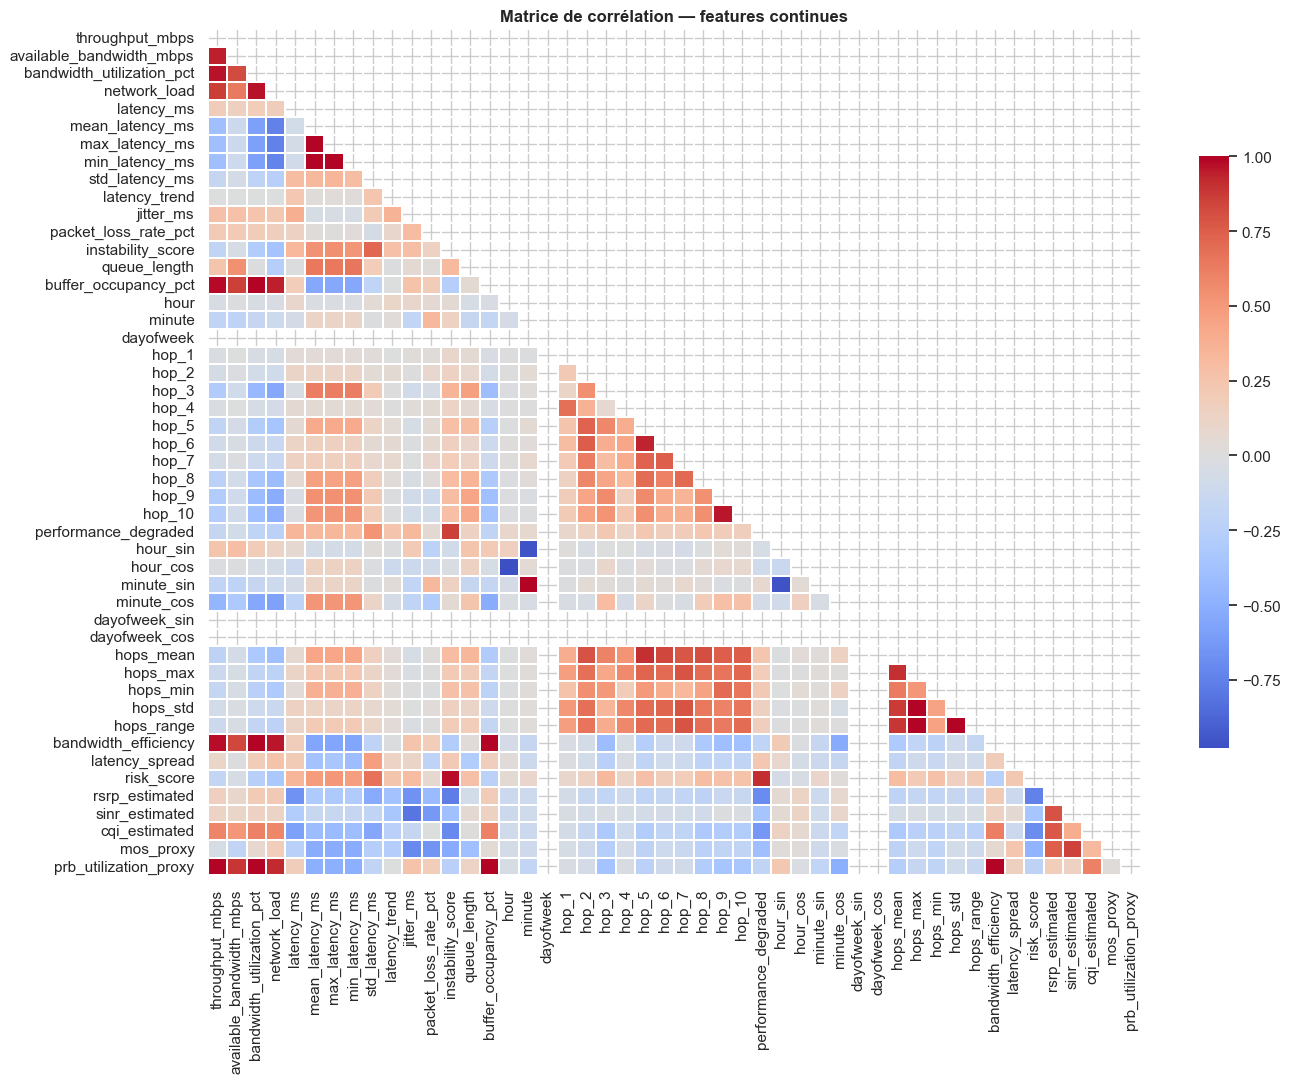


Target encodée : {'Bon': 0, 'Faible': 1, 'Mauvais': 2, 'Très mauvais': 3}


In [6]:
if not globals().get("_df_loaded") or df.empty:
    print("⏭️  Sélection features ignorée")
else:
    cols_to_drop = [c for c in ["timestamp","congestion_level"] if c in df.columns]
    target_candidates = ["rsrp_category","rsrp_category_label","rsrp_cat","category","y","label"]
    target_col = next((c for c in target_candidates if c in df.columns), None)
    binary_cols = [c for c in ["spike","ho_failure_proxy","coverage_hole_proxy","peak_offpeak_indicator"] if c in df.columns]

    feature_cols = [c for c in df.columns if c not in cols_to_drop + ([target_col] if target_col else [])]
    num_features  = [c for c in feature_cols if df[c].dtype in ["float64","int64","int32","float32"]]
    cont_features = [c for c in num_features if c not in binary_cols]

    print(f"Features totales    : {len(feature_cols)}")
    print(f"  • Continues       : {len(cont_features)}")
    print(f"  • Binaires        : {len(binary_cols)}")
    print(f"  • Supprimées      : {cols_to_drop}")

    if len(cont_features) >= 4:
        # ── Heatmap corrélation ───────────────────────────────
        corr = df[cont_features].corr()
        fig, ax = plt.subplots(figsize=(min(14, len(cont_features)), min(11, len(cont_features)-1)))
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=len(cont_features)<=16,
                    fmt=".2f", cmap="coolwarm", center=0,
                    linewidths=0.3, ax=ax, cbar_kws={"shrink":0.7},
                    annot_kws={"size":7})
        ax.set_title("Matrice de corrélation — features continues", fontweight="bold", fontsize=12)
        plt.tight_layout(); plt.show()

    # Encode target
    if target_col:
        le = LabelEncoder()
        y  = le.fit_transform(df[target_col])
        print(f"\nTarget encodée : {dict(zip(le.classes_, le.transform(le.classes_)))}")


## 🔍 Cellule 6 — Analyse et traitement des outliers

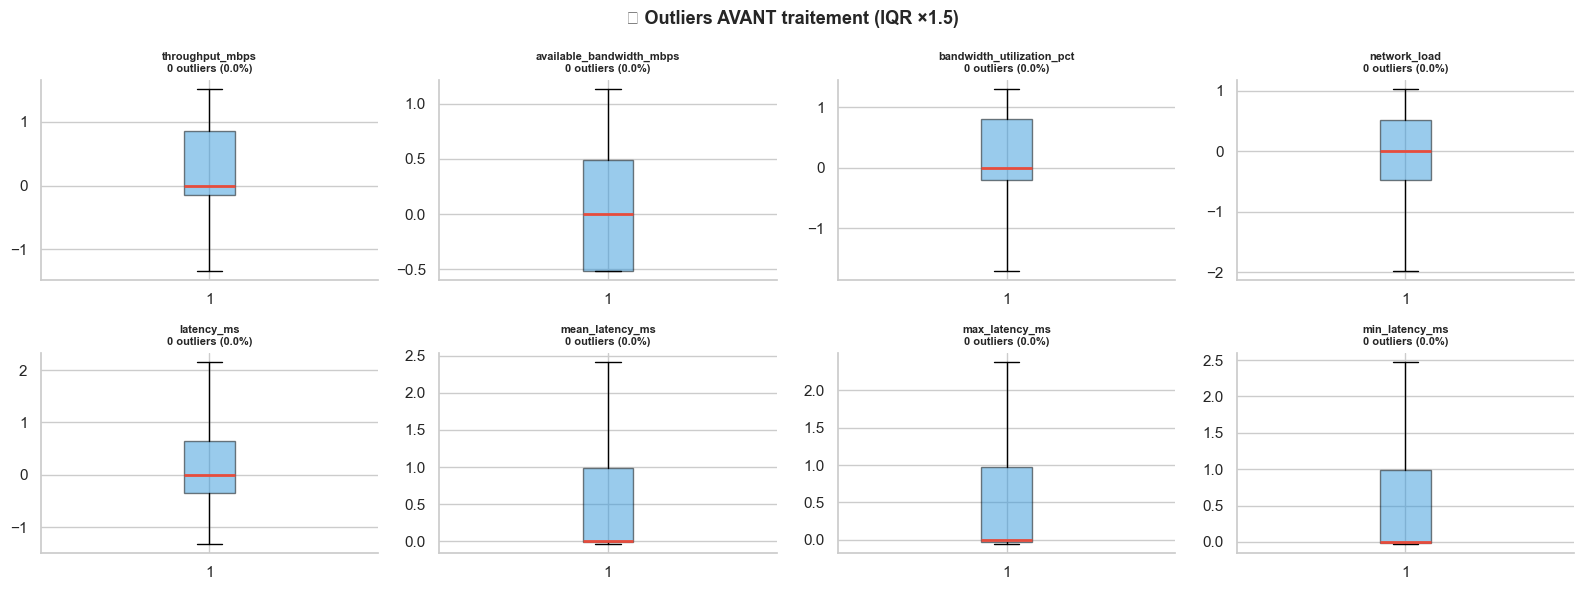

✅ Winsorizing (1%–99%) appliqué — 1,486 valeurs écrêtées


In [7]:
if not globals().get("_df_loaded") or df.empty:
    print("⏭️  Outlier analysis ignorée")
else:
    key_feats = [c for c in cont_features if c in df.columns][:8]
    X_raw = df[key_feats].copy()

    # ── Boxplots outliers AVANT traitement ────────────────────
    ncols = 4; nrows = max(1, (len(key_feats)+3)//4)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*3))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for i, col in enumerate(key_feats):
        q1, q3 = X_raw[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        n_out = ((X_raw[col] < q1-1.5*iqr) | (X_raw[col] > q3+1.5*iqr)).sum()
        pct   = n_out/len(X_raw)*100
        axes[i].boxplot(X_raw[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor="#3498db", alpha=0.5),
                        medianprops=dict(color="#e74c3c", linewidth=2),
                        flierprops=dict(marker=".", markersize=3, alpha=0.3, color="#e74c3c"))
        axes[i].set_title(f"{col}\n{n_out:,} outliers ({pct:.1f}%)", fontsize=8, fontweight="bold")
        axes[i].spines[["top","right"]].set_visible(False)
    for j in range(len(key_feats), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("🔍 Outliers AVANT traitement (IQR ×1.5)", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

    # ── IQR capping (Winsorizing) ─────────────────────────────
    X_capped = df[feature_cols].copy()
    n_capped_total = 0
    for col in cont_features:
        if col not in X_capped.columns: continue
        q1, q3 = X_capped[col].quantile([0.01, 0.99])
        n = ((X_capped[col] < q1) | (X_capped[col] > q3)).sum()
        X_capped[col] = X_capped[col].clip(lower=q1, upper=q3)
        n_capped_total += n
    print(f"✅ Winsorizing (1%–99%) appliqué — {n_capped_total:,} valeurs écrêtées")


## 🔄 Cellule 7 — Transformations (log1p + RobustScaler)

✅ KNN Imputer (k=5) — NaN restants : 0

📐 Features à transformer (skew > 1) : 25
   latency_ms                               skew = +1.016
   mean_latency_ms                          skew = +1.100
   max_latency_ms                           skew = +1.076
   min_latency_ms                           skew = +1.121
   jitter_ms                                skew = +1.252
   hop_1                                    skew = +3.645
   hop_2                                    skew = +5.090
   hop_3                                    skew = +1.302
✅ Log1p appliqué — skewness améliorée sur 24/48 features
✅ RobustScaler (IQR 5–95%) appliqué


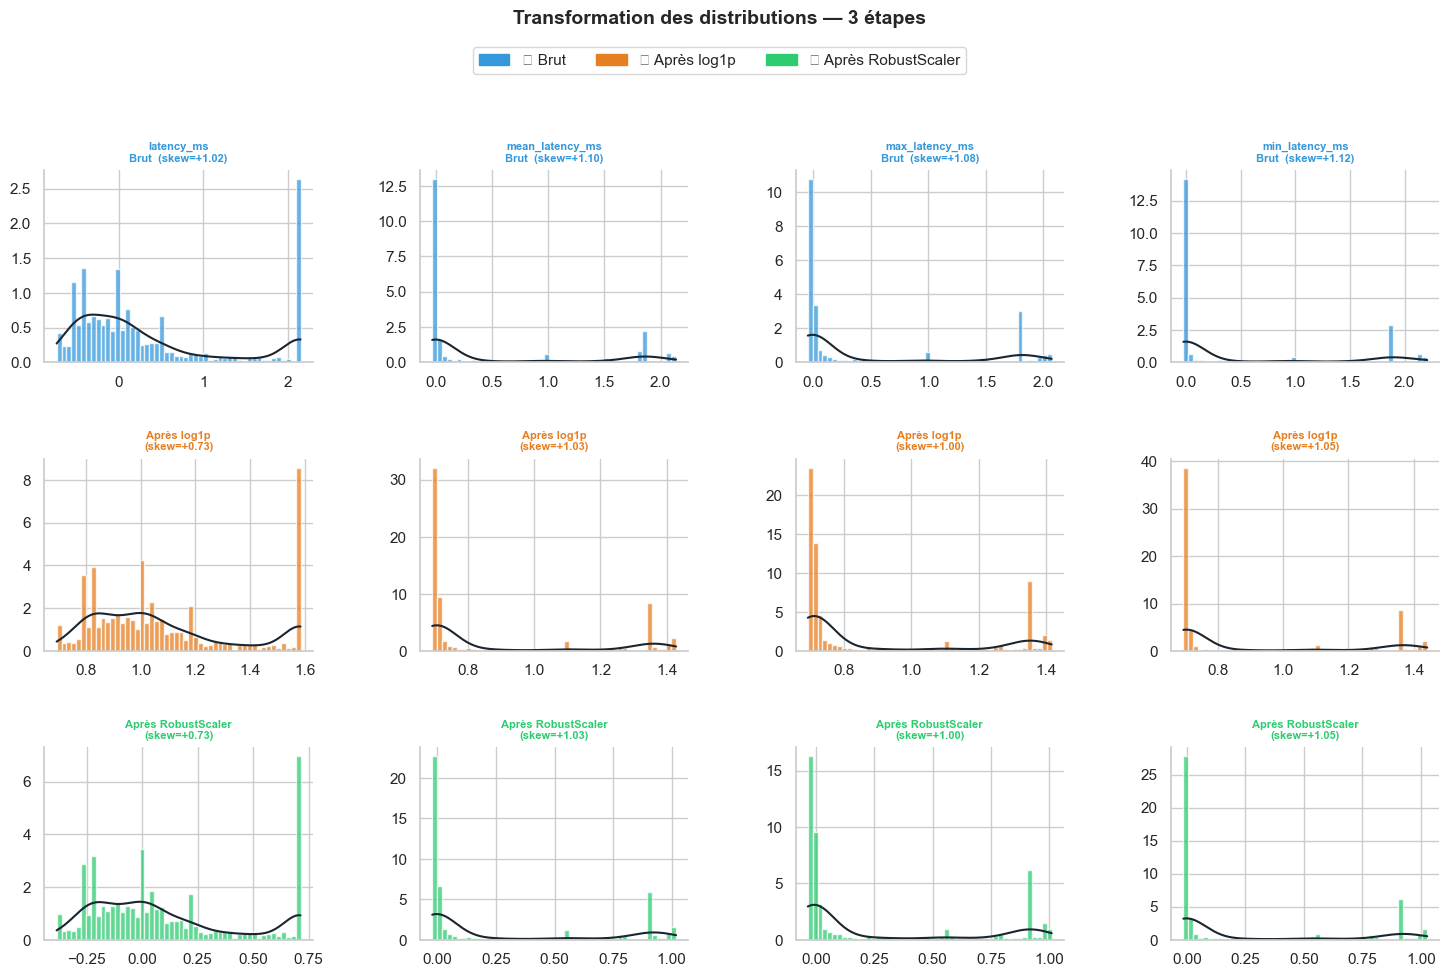

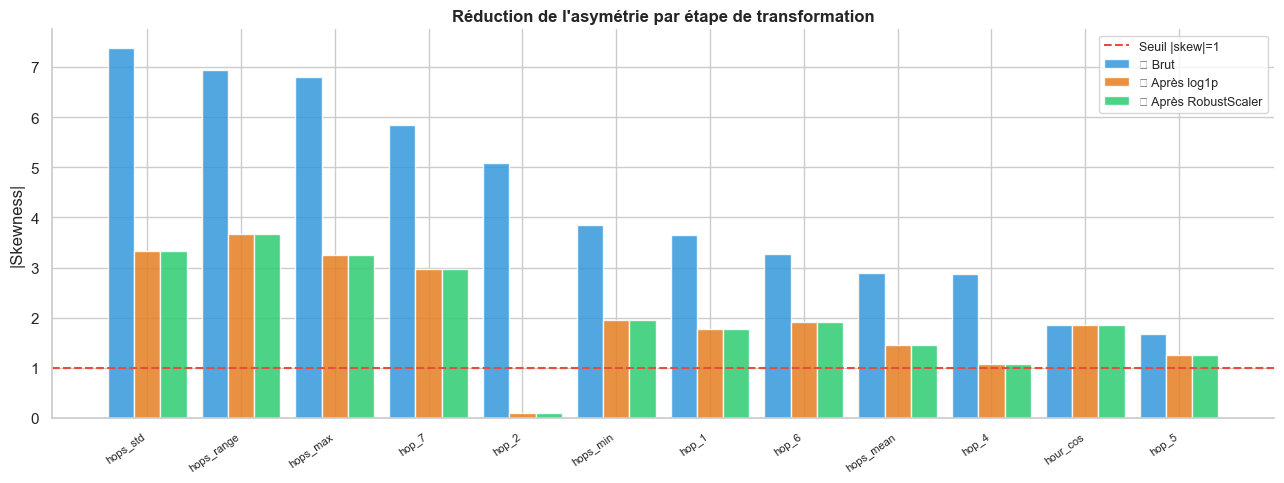


  Skewness moyenne  brut        : 1.594
  Skewness moyenne  après log1p : 0.959
  Skewness moyenne  après scaler: 0.959


In [8]:
if not globals().get("_df_loaded") or df.empty:
    print("⏭️  Transformations ignorées")
else:
    # ── Imputation KNN ────────────────────────────────────────
    knn_imputer = KNNImputer(n_neighbors=5, weights="distance")
    X_imputed = pd.DataFrame(
        knn_imputer.fit_transform(X_capped[feature_cols]),
        columns=feature_cols
    )
    print(f"✅ KNN Imputer (k=5) — NaN restants : {X_imputed.isnull().sum().sum()}")

    # ── Détection des features très asymétriques (skew > 1) ──
    skew_before = X_imputed[cont_features].skew()
    log_features = skew_before[skew_before > 1].index.tolist()
    print(f"\n📐 Features à transformer (skew > 1) : {len(log_features)}")
    for col in log_features[:8]:
        print(f"   {col:<40} skew = {skew_before[col]:+.3f}")

    # ── Log1p sur features asymétriques ──────────────────────
    X_transformed = X_imputed.copy()
    for col in log_features:
        if X_transformed[col].min() >= 0:
            X_transformed[col] = np.log1p(X_transformed[col])
        else:
            # shift + log1p pour valeurs négatives
            shift = abs(X_transformed[col].min()) + 1
            X_transformed[col] = np.log1p(X_transformed[col] + shift)

    skew_after = X_transformed[cont_features].skew()
    improved = ((skew_before.abs() - skew_after.abs()) > 0).sum()
    print(f"✅ Log1p appliqué — skewness améliorée sur {improved}/{len(cont_features)} features")

    # ── RobustScaler après transformation ─────────────────────
    scaler = RobustScaler(quantile_range=(5, 95))
    X_scaled = X_transformed.copy()
    X_scaled[cont_features] = scaler.fit_transform(X_transformed[cont_features])
    print(f"✅ RobustScaler (IQR 5–95%) appliqué")

    # ── Visualisation AVANT / APRÈS (KDE + boxplot) ───────────
    viz_feats = [c for c in log_features if c in X_imputed.columns][:4]
    if not viz_feats:
        viz_feats = cont_features[:4]

    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(3, len(viz_feats), hspace=0.5, wspace=0.4)

    colors = {"raw":"#3498db", "log":"#e67e22", "scaled":"#2ecc71"}

    for j, col in enumerate(viz_feats):
        raw    = X_imputed[col].dropna()
        logged = X_transformed[col].dropna()
        scaled = X_scaled[col].dropna()

        # Ligne 1 — brut
        ax1 = fig.add_subplot(gs[0, j])
        ax1.hist(raw, bins=50, color=colors["raw"], alpha=0.75, edgecolor="white", density=True)
        try:
            xr = np.linspace(raw.min(), raw.max(), 200)
            ax1.plot(xr, stats.gaussian_kde(raw)(xr), color="#1a252f", lw=1.5)
        except: pass
        ax1.set_title(f"{col}\nBrut  (skew={skew_before[col]:+.2f})",
                      fontsize=8, fontweight="bold", color=colors["raw"])
        ax1.spines[["top","right"]].set_visible(False)

        # Ligne 2 — après log1p
        ax2 = fig.add_subplot(gs[1, j])
        ax2.hist(logged, bins=50, color=colors["log"], alpha=0.75, edgecolor="white", density=True)
        sk2 = logged.skew()
        try:
            xl = np.linspace(logged.min(), logged.max(), 200)
            ax2.plot(xl, stats.gaussian_kde(logged)(xl), color="#1a252f", lw=1.5)
        except: pass
        ax2.set_title(f"Après log1p\n(skew={sk2:+.2f})",
                      fontsize=8, fontweight="bold", color=colors["log"])
        ax2.spines[["top","right"]].set_visible(False)

        # Ligne 3 — après RobustScaler
        ax3 = fig.add_subplot(gs[2, j])
        ax3.hist(scaled, bins=50, color=colors["scaled"], alpha=0.75, edgecolor="white", density=True)
        sk3 = scaled.skew()
        try:
            xs = np.linspace(scaled.min(), scaled.max(), 200)
            ax3.plot(xs, stats.gaussian_kde(scaled)(xs), color="#1a252f", lw=1.5)
        except: pass
        ax3.set_title(f"Après RobustScaler\n(skew={sk3:+.2f})",
                      fontsize=8, fontweight="bold", color=colors["scaled"])
        ax3.spines[["top","right"]].set_visible(False)

    # Légende globale
    from matplotlib.patches import Patch
    legend = [Patch(color=colors["raw"],    label="① Brut"),
              Patch(color=colors["log"],    label="② Après log1p"),
              Patch(color=colors["scaled"], label="③ Après RobustScaler")]
    fig.legend(handles=legend, loc="upper center", ncol=3, fontsize=11,
               frameon=True, bbox_to_anchor=(0.5, 1.01))
    plt.suptitle("Transformation des distributions — 3 étapes",
                 fontsize=14, fontweight="bold", y=1.04)
    plt.show()

    # ── Skewness avant / après (barplot comparatif) ───────────
    sk_df = pd.DataFrame({
        "Brut":           skew_before.abs(),
        "Après log1p":    X_transformed[cont_features].skew().abs(),
        "Après scaler":   X_scaled[cont_features].skew().abs(),
    }).sort_values("Brut", ascending=False).head(12)

    fig, ax = plt.subplots(figsize=(13, 5))
    x = np.arange(len(sk_df))
    w = 0.28
    ax.bar(x - w, sk_df["Brut"],        w, label="① Brut",            color="#3498db", alpha=0.85)
    ax.bar(x,     sk_df["Après log1p"], w, label="② Après log1p",     color="#e67e22", alpha=0.85)
    ax.bar(x + w, sk_df["Après scaler"],w, label="③ Après RobustScaler",color="#2ecc71",alpha=0.85)
    ax.axhline(1.0, color="#e74c3c", lw=1.5, linestyle="--", label="Seuil |skew|=1")
    ax.set_xticks(x); ax.set_xticklabels(sk_df.index, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("|Skewness|"); ax.legend(fontsize=9)
    ax.set_title("Réduction de l'asymétrie par étape de transformation",
                 fontweight="bold", fontsize=12)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()
    print(f"\n  Skewness moyenne  brut        : {skew_before.abs().mean():.3f}")
    print(f"  Skewness moyenne  après log1p : {X_transformed[cont_features].skew().abs().mean():.3f}")
    print(f"  Skewness moyenne  après scaler: {X_scaled[cont_features].skew().abs().mean():.3f}")


## 🎻 Cellule 8 — Visualisation finale (avant vs après)

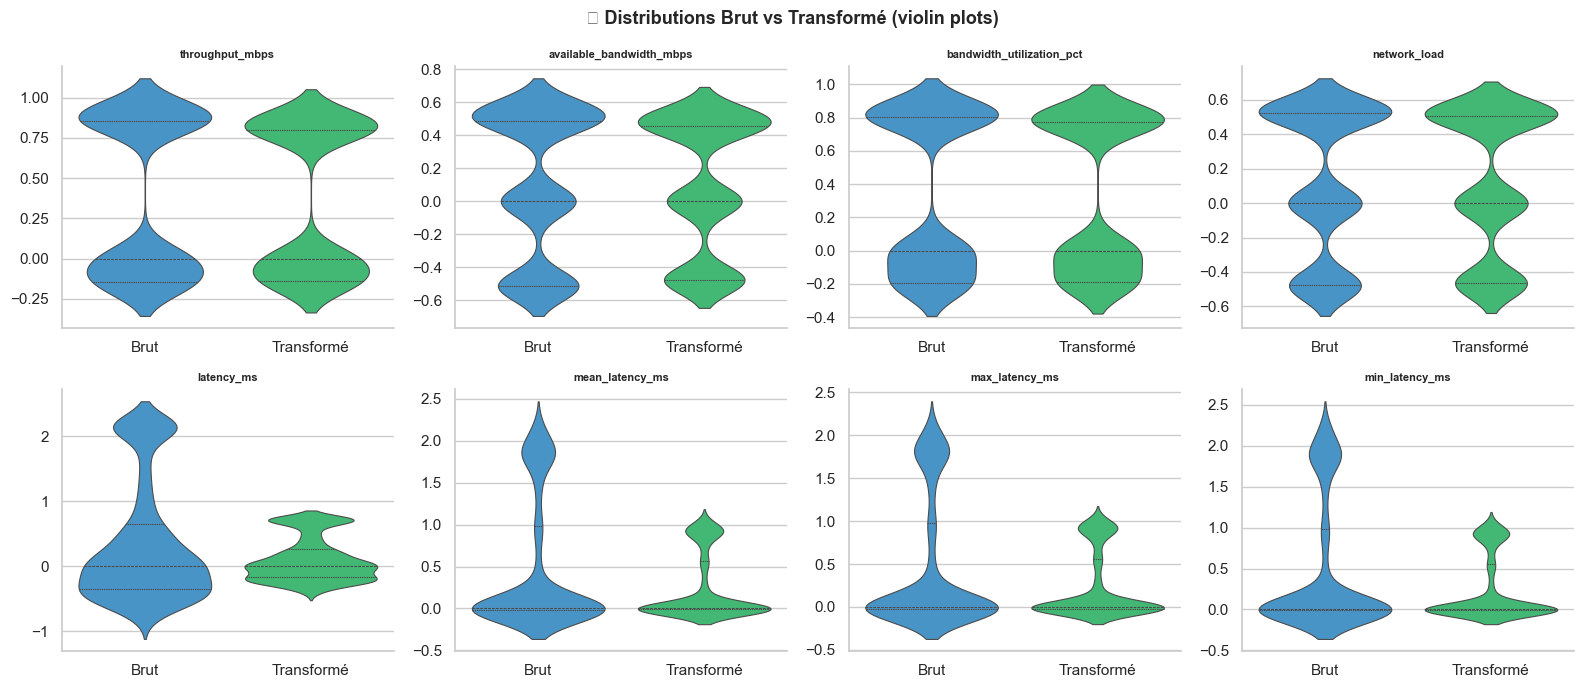


📊 Statistiques comparatives (brut vs final) :
                           Brut — mean  Brut — std  Brut — skew  Final — mean  Final — std  Final — skew
throughput_mbps                  0.382       0.481        0.049         0.359        0.452         0.049
available_bandwidth_mbps         0.111       0.434       -0.394         0.103        0.403        -0.394
bandwidth_utilization_pct        0.342       0.463        0.013         0.330        0.447         0.013
network_load                     0.133       0.421       -0.379         0.129        0.410        -0.379
latency_ms                       0.353       0.920        1.016         0.101        0.335         0.729
mean_latency_ms                  0.495       0.785        1.100         0.250        0.391         1.029
max_latency_ms                   0.483       0.766        1.076         0.249        0.390         1.003
min_latency_ms                   0.502       0.804        1.121         0.249        0.391         1.050


In [9]:
if not globals().get("_df_loaded") or df.empty:
    print("⏭️  Boxplot final ignoré")
else:
    # ── Boxplots APRÈS traitement ─────────────────────────────
    key_feats = [c for c in cont_features if c in X_scaled.columns][:8]
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.flatten()
    palette = sns.color_palette("Set2", len(key_feats))

    for i, col in enumerate(key_feats):
        before = X_imputed[col].dropna()
        after  = X_scaled[col].dropna()
        # Violin + strip avant/après côte à côte
        data = pd.DataFrame({
            "Valeur": list(before) + list(after),
            "Étape":  ["Brut"]*len(before) + ["Transformé"]*len(after)
        })
        sns.violinplot(data=data, x="Étape", y="Valeur",
                       palette=["#3498db","#2ecc71"], inner="quartile",
                       ax=axes[i], linewidth=0.8)
        axes[i].set_title(col, fontsize=8, fontweight="bold")
        axes[i].set_xlabel(""); axes[i].set_ylabel("")
        axes[i].spines[["top","right"]].set_visible(False)
    for j in range(len(key_feats), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("🎻 Distributions Brut vs Transformé (violin plots)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

    # ── Statistiques comparatives ─────────────────────────────
    stats_df = pd.DataFrame({
        "Brut — mean":      X_imputed[key_feats].mean().round(3),
        "Brut — std":       X_imputed[key_feats].std().round(3),
        "Brut — skew":      X_imputed[key_feats].skew().round(3),
        "Final — mean":     X_scaled[key_feats].mean().round(3),
        "Final — std":      X_scaled[key_feats].std().round(3),
        "Final — skew":     X_scaled[key_feats].skew().round(3),
    })
    print("\n📊 Statistiques comparatives (brut vs final) :")
    print(stats_df.to_string())


## 💾 Cellule 9 — Sauvegarde

In [10]:
if not globals().get("_df_loaded") or df.empty:
    print("⏭️  Sauvegarde ignorée")
else:
    # Chemin de sortie compatible Windows + Colab
    if os.path.exists("/content"):
        output_dir = "/content/outputs"
    else:
        output_dir = os.path.join(os.path.expanduser("~"), "Downloads", "qos_output_prepared")
    os.makedirs(output_dir, exist_ok=True)

    # Sauvegardes
    X_scaled.to_csv(f"{output_dir}/X_prepared.csv", index=False)
    if "le" in globals() and "y" in globals():
        y_df = pd.DataFrame({"encoded": y, "label": df[target_col].values})
        y_df.to_csv(f"{output_dir}/y_target.csv", index=False)
    joblib.dump(knn_imputer, f"{output_dir}/knn_imputer.pkl")
    joblib.dump(scaler,      f"{output_dir}/robust_scaler.pkl")
    if "le" in globals():
        joblib.dump(le, f"{output_dir}/label_encoder.pkl")

    print(f"📁 Fichiers sauvegardés dans : {output_dir}")
    for fname in os.listdir(output_dir):
        size = os.path.getsize(f"{output_dir}/{fname}")
        print(f"  ✅ {fname:<40} {size/1024:.1f} KB")


📁 Fichiers sauvegardés dans : /content/outputs
  ✅ knn_imputer.pkl                          1102.2 KB
  ✅ label_encoder.pkl                        0.5 KB
  ✅ qos_prepared_full.csv                    1921.0 KB
  ✅ robust_scaler.pkl                        2.1 KB
  ✅ X_prepared.csv                           1932.1 KB
  ✅ y_target.csv                             19.9 KB


## ✅ Cellule 10 — Résumé final

In [11]:
if not globals().get("_df_loaded") or df.empty:
    print("⏭️  Résumé ignoré")
else:
    W = 58
    print("═"*W)
    print("  RÉSUMÉ PIPELINE DATA PREPARATION".center(W))
    print("═"*W)
    print(f"  Lignes traitées  : {X_scaled.shape[0]:>10,}")
    print(f"  Features (X)     : {X_scaled.shape[1]:>10}")
    if "le" in globals():
        print(f"  Classes target   : {len(le.classes_):>10}  → {list(le.classes_)}")
    print("─"*W)
    print(f"  Étape 1 — Winsorizing (1%–99%)   : {n_capped_total:>6,} valeurs écrêtées")
    print(f"  Étape 2 — KNN Imputer (k=5)       : {X_imputed.isnull().sum().sum():>6} NaN restants")
    print(f"  Étape 3 — Log1p                   : {len(log_features):>6} features transformées")
    print(f"  Étape 4 — RobustScaler (5–95%)    : {len(cont_features):>6} features normalisées")
    sk_mean_before = df[cont_features].skew().abs().mean() if cont_features else 0
    sk_mean_after  = X_scaled[cont_features].skew().abs().mean() if cont_features else 0
    print(f"─"*W)
    print(f"  Skewness moy. avant  : {sk_mean_before:.3f}")
    print(f"  Skewness moy. après  : {sk_mean_after:.3f}")
    print(f"  Réduction            : {(1 - sk_mean_after/max(sk_mean_before,1e-9))*100:.1f}%")
    print("═"*W)
    print("  ✅ Pipeline data preparation terminé !".center(W))
    print("═"*W)


══════════════════════════════════════════════════════════
              RÉSUMÉ PIPELINE DATA PREPARATION            
══════════════════════════════════════════════════════════
  Lignes traitées  :      2,408
  Features (X)     :         52
  Classes target   :          4  → ['Bon', 'Faible', 'Mauvais', 'Très mauvais']
──────────────────────────────────────────────────────────
  Étape 1 — Winsorizing (1%–99%)   :  1,486 valeurs écrêtées
  Étape 2 — KNN Imputer (k=5)       :      0 NaN restants
  Étape 3 — Log1p                   :     25 features transformées
  Étape 4 — RobustScaler (5–95%)    :     48 features normalisées
──────────────────────────────────────────────────────────
  Skewness moy. avant  : 6.364
  Skewness moy. après  : 0.959
  Réduction            : 84.9%
══════════════════════════════════════════════════════════
           ✅ Pipeline data preparation terminé !          
══════════════════════════════════════════════════════════


# DSO1 +DSO2 — Surveillance Réseau Temps Réel
### Jupyter Lab / Jupyter Notebook / VS Code
**Agent 1** : capture réseau (54 features) · **Agent 2** : classification & alertes  
**Ordre :** Cellule 1 → Cellule 2 → Cellule 3 (START) → Cellule 4 (test optionnel)


## 📦 Cellule 1 — Installation des dépendances

In [12]:
# ═══════════════════════════════════════════════════════════════
# CELLULE 1 — Installation
# Exécuter une seule fois, puis redémarrer le kernel si nécessaire
# ═══════════════════════════════════════════════════════════════
import subprocess, sys

packages = ['ping3', 'icmplib', 'psutil', 'requests', 'ipywidgets', 'jupyterlab']
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    status = '✅' if result.returncode == 0 else '❌'
    print(f'{status} {pkg}')

print()
print('⚠️  Si premier lancement → redémarrer le kernel (Kernel > Restart)')
print('   puis exécuter les cellules 1 → 2 → 3')


✅ ping3
✅ icmplib
✅ psutil
✅ requests
✅ ipywidgets
✅ jupyterlab

⚠️  Si premier lancement → redémarrer le kernel (Kernel > Restart)
   puis exécuter les cellules 1 → 2 → 3


## ⚙️ Cellule 2 — Configuration

In [13]:
# ═══════════════════════════════════════════════════════════════
# CELLULE 2 — CONFIGURATION
# Seuils selon Cisco QoS Design Guide + ITU-T G.114 + 3GPP TS 36
# ═══════════════════════════════════════════════════════════════
import os

# ── Réseau
TARGET_HOST  = '8.8.8.8'
TARGET_HOST2 = '1.1.1.1'
PING_COUNT   = 5
MAX_HOPS     = 10
INTERVAL_SEC = 10

# ── Chemins CSV
OUTPUT_DIR  = os.path.join(os.getcwd(), 'qos_output')
CSV_LIVE    = os.path.join(OUTPUT_DIR, 'monitoring_live.csv')
CSV_ALERTS  = os.path.join(OUTPUT_DIR, 'alerts_log.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Webhook
WEBHOOK_URL = None

# ── Seuils Cisco / ITU-T / 3GPP
THRESHOLDS = {
    # Latence — ITU-T G.114
    'latency_ms':                (150,   200,   False),
    'mean_latency_ms':           (150,   200,   False),
    'max_latency_ms':            (200,   400,   False),
    'std_latency_ms':            (20,    50,    False),
    # Jitter — ITU-T G.114
    'jitter_ms':                 (30,    50,    False),
    'latency_spread':            (20,    50,    False),
    'latency_trend':             (50,    100,   False),
    # Perte paquets — Cisco QoS
    'packet_loss_rate_pct':      (1.0,   5.0,   False),
    'risk_score':                (0.4,   0.6,   False),
    'instability_score':         (5.0,   15.0,  False),
    # Bande passante — Cisco (seuils utilisation réseau)
    'bandwidth_utilization_pct': (50.0,  75.0,  False),
    'network_load':              (0.5,   0.75,  False),
    # Charge système
    'queue_length':              (70,    90,    False),
    'buffer_occupancy_pct':      (75,    90,    False),
    'prb_utilization_proxy':     (50.0,  75.0,  False),
    # Hops
    'hops_mean':                 (50,    100,   False),
    'hops_max':                  (150,   300,   False),
    'hops_std':                  (30,    60,    False),
    'hops_range':                (100,   200,   False),
    # ── throughput et available_bandwidth SUPPRIMÉS
    #    (psutil mesure le trafic local, pas la vraie bande passante)
    # MOS — ITU-T P.800
    'mos_proxy':                 (3.6,   3.1,   True),
    # Signal LTE — 3GPP TS 36.133
    'rsrp_estimated':            (-80,   -100,  True),
    'sinr_estimated':            (0,     -3,    True),
    'cqi_estimated':             (7,     4,     True),
    # Efficacité bande passante
    'bandwidth_efficiency':      (0.3,   0.1,   True),
}

BINARY_FLAGS = {
    'spike':               'Pic de latence (ITU-T G.114)',
    'ho_failure_proxy':    'Échec handover (3GPP TS 36)',
    'coverage_hole_proxy': 'Zone couverture faible (RSRP < -100 dBm)',
    'performance_degraded':'Dégradation performance (Cisco QoS)',
}

print('✅ Configuration chargée — seuils Cisco/ITU-T/3GPP')
print(f'   Cible      : {TARGET_HOST} / {TARGET_HOST2}')
print(f'   Intervalle : {INTERVAL_SEC}s')
print(f'   CSV live   : {CSV_LIVE}')
print(f'   CSV alertes: {CSV_ALERTS}')
print(f'   Webhook    : {WEBHOOK_URL or "désactivé"}')
print(f'   Seuils     : {len(THRESHOLDS)} features continues + {len(BINARY_FLAGS)} binaires')

✅ Configuration chargée — seuils Cisco/ITU-T/3GPP
   Cible      : 8.8.8.8 / 1.1.1.1
   Intervalle : 10s
   CSV live   : c:\Users\ayoub\Downloads\qos_output\monitoring_live.csv
   CSV alertes: c:\Users\ayoub\Downloads\qos_output\alerts_log.csv
   Webhook    : désactivé
   Seuils     : 24 features continues + 4 binaires


## 🚀 Cellule 3 — Agent 1 + Agent 2 + Dashboard temps réel

In [14]:
# ── Vérification des dépendances ───────────────────────────────
_required = ['CSV_LIVE', 'CSV_ALERTS', 'TARGET_HOST', 'TARGET_HOST2',
             'PING_COUNT', 'MAX_HOPS', 'INTERVAL_SEC',
             'THRESHOLDS', 'BINARY_FLAGS', 'WEBHOOK_URL']

_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(
        f"❌ Variables manquantes : {_missing}\n"
        f"   → Exécute d'abord la Cellule 2 (Configuration) !"
    )
print('✅ Dépendances OK — chargement des agents...')

✅ Dépendances OK — chargement des agents...


In [15]:
# ═══════════════════════════════════════════════════════════════
# CELLULE 3 — AGENT 1 + AGENT 2 + DASHBOARD
# Jupyter Lab / Notebook / VS Code — sans widgets
# ═══════════════════════════════════════════════════════════════
import psutil, time, os, csv, json as _json, math, statistics
import requests, threading, queue
from ping3 import ping
from icmplib import traceroute
from datetime import datetime
from IPython.display import clear_output

# ────────────────────────────────────────────────────────────────
# ÉTAT PARTAGÉ + FILE INTER-AGENTS
# ────────────────────────────────────────────────────────────────
state = {
    'running':       False,
    'total':         0,
    'alerts_count':  0,
    'last_row':      None,
    'last_analysis': None,
    'a1_log':        [],   # historique logs Agent 1
    'a2_log':        [],   # historique logs Agent 2
    'api_status':    '—',
}
data_queue      = queue.Queue(maxsize=5)   # Agent2 → DSO3  : (row, analysis) tuple
a1_to_a2_queue  = queue.Queue(maxsize=5)   # Agent1 → Agent2: raw row
alert_history   = []

# ────────────────────────────────────────────────────────────────
# AGENT 1 — CAPTURE RÉSEAU (54 features)
# ────────────────────────────────────────────────────────────────
def _save_csv(row, path):
    exists = os.path.isfile(path)
    with open(path, 'a', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=row.keys(), delimiter=';')
        if not exists:
            w.writeheader()
        w.writerow(row)

def _a1_log(msg):
    ts = datetime.now().strftime('%H:%M:%S')
    state['a1_log'].insert(0, f'[{ts}] {msg}')
    state['a1_log'] = state['a1_log'][:20]

def agent1_capture():
    ts  = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    now = datetime.now()
    row = {'timestamp': ts}

    # 1. LATENCE
    pings, host = [], TARGET_HOST
    for _ in range(PING_COUNT):
        try:
            r = ping(TARGET_HOST, timeout=2, unit='ms')
            if r: pings.append(r)
        except: pass
    if not pings:
        host = TARGET_HOST2
        for _ in range(PING_COUNT):
            try:
                r = ping(TARGET_HOST2, timeout=2, unit='ms')
                if r: pings.append(r)
            except: pass

    row['latency_ms']           = round(sum(pings)/len(pings), 4) if pings else -1
    row['mean_latency_ms']      = row['latency_ms']
    row['min_latency_ms']       = round(min(pings), 4)            if pings else -1
    row['max_latency_ms']       = round(max(pings), 4)            if pings else -1
    row['std_latency_ms']       = round(statistics.stdev(pings), 4) if len(pings)>1 else 0.0
    row['jitter_ms']            = round(row['max_latency_ms'] - row['min_latency_ms'], 4) if pings else -1
    row['latency_spread']       = row['std_latency_ms']
    row['packet_loss_rate_pct'] = round((PING_COUNT - len(pings)) / PING_COUNT * 100, 2)
    row['spike']                = 1 if row['latency_ms'] > 200 else 0
    prev = float(state['last_row']['latency_ms']) if state['last_row'] else row['latency_ms']
    row['latency_trend']        = round(row['latency_ms'] - prev, 4)

    # 2. BANDE PASSANTE
    net1 = psutil.net_io_counters(); time.sleep(1); net2 = psutil.net_io_counters()
    s = (net2.bytes_sent - net1.bytes_sent) * 8
    r = (net2.bytes_recv - net1.bytes_recv) * 8
    row['throughput_mbps']            = round(r / 1e6, 4)
    row['available_bandwidth_mbps']   = round((s + r) / 1e6, 4)
    row['bandwidth_utilization_pct']  = round(min(r / 1e8 * 100, 100), 4)
    row['bandwidth_efficiency']       = round(r / max(s + r, 1), 4)
    row['network_load']               = round(row['bandwidth_utilization_pct'] / 100, 4)

    # 3. QUALITÉ RÉSEAU
    drops = (net2.dropin + net2.dropout) - (net1.dropin + net1.dropout)
    pkts  = max(net2.packets_recv - net1.packets_recv, 1)
    row['packet_loss_rate_pct'] = round(drops / pkts * 100, 4)
    row['instability_score']    = round(row['jitter_ms'] * row['packet_loss_rate_pct'] / 100, 4)
    row['risk_score']           = round((row['latency_ms']/300 + row['packet_loss_rate_pct']/100) / 2, 4)

    # 4. CHARGE SYSTÈME
    row['buffer_occupancy_pct']  = round(psutil.virtual_memory().percent, 4)
    row['queue_length']          = round(psutil.cpu_percent(interval=0.2), 4)
    row['congestion_level']      = 0
    row['prb_utilization_proxy'] = row['bandwidth_utilization_pct']

    # 5. HOPS
    hl = []
    try:
        hops = traceroute(host, max_hops=MAX_HOPS, timeout=1)
        hl = [h.avg_rtt for h in hops if h.avg_rtt > 0]
    except: pass
    for i in range(1, 11):
        row[f'hop_{i}'] = round(hl[i-1], 4) if i <= len(hl) else 0.0
    row['hops_mean']  = round(sum(hl)/len(hl), 4) if hl else 0.0
    row['hops_max']   = round(max(hl), 4)          if hl else 0.0
    row['hops_min']   = round(min(hl), 4)          if hl else 0.0
    row['hops_std']   = round(statistics.stdev(hl), 4) if len(hl) > 1 else 0.0
    row['hops_range'] = round(row['hops_max'] - row['hops_min'], 4)

    # 6. SIGNAL ESTIMÉ
    row['rsrp_estimated'] = round(-70 - row['latency_ms'] * 0.1, 4)
    row['sinr_estimated'] = round(20 - row['packet_loss_rate_pct'] * 2, 4)
    row['cqi_estimated']  = max(1, min(15, int(15 - row['packet_loss_rate_pct'] / 7)))
    row['mos_proxy']      = round(max(1, 4.5 - row['packet_loss_rate_pct']*0.1 - row['latency_ms']*0.005), 4)

    # 7. FLAGS BINAIRES
    row['ho_failure_proxy']     = 1 if row['packet_loss_rate_pct'] > 5 else 0
    row['coverage_hole_proxy']  = 1 if row['rsrp_estimated'] < -100    else 0
    row['performance_degraded'] = 1 if (row['latency_ms'] > 150 or row['packet_loss_rate_pct'] > 3) else 0

    # 8. CATÉGORIE RSRP
    rsrp = row['rsrp_estimated']
    row['rsrp_category'] = ('Bon'          if rsrp >= -80  else
                            'Mauvais'      if rsrp >= -90  else
                            'Faible'       if rsrp >= -100 else
                            'Très mauvais')

    # 9. TEMPOREL
    row['hour']                   = now.hour
    row['minute']                 = now.minute
    row['dayofweek']              = now.weekday()
    row['hour_sin']               = round(math.sin(2*math.pi*now.hour/24), 4)
    row['hour_cos']               = round(math.cos(2*math.pi*now.hour/24), 4)
    row['minute_sin']             = round(math.sin(2*math.pi*now.minute/60), 4)
    row['minute_cos']             = round(math.cos(2*math.pi*now.minute/60), 4)
    row['dayofweek_sin']          = round(math.sin(2*math.pi*now.weekday()/7), 4)
    row['dayofweek_cos']          = round(math.cos(2*math.pi*now.weekday()/7), 4)
    row['peak_offpeak_indicator'] = 1 if 8 <= now.hour <= 22 else 0
    return row

def agent1_loop():
    _a1_log('démarré')
    while state['running']:
        state['total'] += 1
        n = state['total']
        _a1_log(f'⏱  capture #{n} en cours...')
        try:
            row = agent1_capture()
            state['last_row'] = row
            _save_csv(row, CSV_LIVE)
            try: a1_to_a2_queue.put_nowait(row)  # → Agent2
            except: pass
            _a1_log(f'✅ #{n} — {len(row)} features — latence {row["latency_ms"]} ms')
        except Exception as e:
            _a1_log(f'❌ #{n} erreur: {e}')
        for _ in range(INTERVAL_SEC):
            if not state['running']: break
            time.sleep(1)
    _a1_log(f'⏹  arrêté après {state["total"]} captures')

# ────────────────────────────────────────────────────────────────
# AGENT 2 — CLASSIFICATION & ALERTES
# ────────────────────────────────────────────────────────────────
def _a2_log(msg):
    ts = datetime.now().strftime('%H:%M:%S')
    state['a2_log'].insert(0, f'[{ts}] {msg}')
    state['a2_log'] = state['a2_log'][:20]

def agent2_classify(row):
    alerts = []
    for metric, (warn, crit, inv) in THRESHOLDS.items():
        val = row.get(metric)
        if val is None or val == -1: continue
        v = float(val)
        level = ('CRITICAL' if (v <= crit if inv else v >= crit) else
                 'WARNING'  if (v <= warn if inv else v >= warn) else 'OK')
        if level != 'OK':
            alerts.append({
                'metric':    metric,
                'value':     round(v, 4),
                'threshold': crit if level == 'CRITICAL' else warn,
                'level':     level,
            })
    for metric, desc in BINARY_FLAGS.items():
        if int(float(row.get(metric, 0))) == 1:
            alerts.append({'metric': metric, 'value': 1,
                           'description': desc, 'level': 'CRITICAL'})
    has_crit = any(a['level'] == 'CRITICAL' for a in alerts)
    return {
        'alerts':       alerts,
        'severity':     'CRITICAL' if has_crit else ('WARNING' if alerts else 'OK'),
        'has_critical': has_crit,
        'rsrp_class':   row.get('rsrp_category', '?'),
        'n_critical':   sum(1 for a in alerts if a['level'] == 'CRITICAL'),
        'n_warning':    sum(1 for a in alerts if a['level'] == 'WARNING'),
    }

def build_payload(row, analysis):
    return {
        'agent':     'QoS-Agent2-Classifier',
        'timestamp':  row.get('timestamp', ''),
        'target':     TARGET_HOST,
        'severity':   analysis['severity'],
        'rsrp_class': analysis['rsrp_class'],
        'n_critical': analysis['n_critical'],
        'n_warning':  analysis['n_warning'],
        'alerts':     analysis['alerts'],
        'metrics':    {k: row.get(k) for k in [
            'latency_ms','mean_latency_ms','max_latency_ms','jitter_ms','latency_trend',
            'packet_loss_rate_pct','risk_score','instability_score',
            'throughput_mbps','bandwidth_utilization_pct','mos_proxy',
            'rsrp_estimated','sinr_estimated','cqi_estimated','hops_mean',
            'buffer_occupancy_pct','queue_length','spike','ho_failure_proxy',
            'coverage_hole_proxy','performance_degraded','rsrp_category',
        ]}
    }

def send_webhook(payload):
    if not WEBHOOK_URL: return 'désactivé'
    try:
        r = requests.post(WEBHOOK_URL, json=payload, timeout=5,
                          headers={'Content-Type': 'application/json'})
        r.raise_for_status()
        return f'HTTP {r.status_code} ✅'
    except Exception as e:
        return f'Erreur: {e}'

def agent2_loop():
    _a2_log('démarré — en écoute')
    while state['running']:
        try: row = a1_to_a2_queue.get(timeout=2)  # ← Agent1 (raw row)
        except: continue
        try:
            analysis = agent2_classify(row)
            state['last_analysis'] = analysis
            # Forward enriched payload (row + classification) to DSO3 via data_queue
            try: data_queue.put_nowait((row, analysis))
            except queue.Full: pass   # DSO3 too slow — drop silently

            if analysis['severity'] != 'OK':
                state['alerts_count'] += 1
                # Sauvegarde CSV alertes
                exists = os.path.isfile(CSV_ALERTS)
                with open(CSV_ALERTS, 'a', newline='', encoding='utf-8') as f:
                    fw = csv.DictWriter(f, delimiter=';', fieldnames=[
                        'timestamp','severity','rsrp_class',
                        'metric','value','threshold','level','description'])
                    if not exists: fw.writeheader()
                    for a in analysis['alerts']:
                        fw.writerow({
                            'timestamp':   row['timestamp'],
                            'severity':    analysis['severity'],
                            'rsrp_class':  analysis['rsrp_class'],
                            'metric':      a.get('metric',''),
                            'value':       a.get('value',''),
                            'threshold':   a.get('threshold',''),
                            'level':       a['level'],
                            'description': a.get('description', a.get('metric','')),
                        })
                if WEBHOOK_URL:
                    state['api_status'] = send_webhook(build_payload(row, analysis))
                _a2_log(f'🚨 {analysis["severity"]} — {analysis["n_critical"]}C {analysis["n_warning"]}W alertes')
            else:
                _a2_log(f'✅ OK — RSRP: {analysis["rsrp_class"]}')

        except Exception as e:
            _a2_log(f'❌ erreur: {e}')
    _a2_log(f'⏹  arrêté — {state["alerts_count"]} alertes déclenchées')

# ────────────────────────────────────────────────────────────────
# DASHBOARD — affichage séparé Agent 1 / Agent 2
# ────────────────────────────────────────────────────────────────
GROUPS_A1 = {
    '⏱️  Latence':       ['latency_ms','mean_latency_ms','min_latency_ms','max_latency_ms',
                          'std_latency_ms','jitter_ms','latency_spread','latency_trend','spike'],
    '📶 Bande passante': ['throughput_mbps','available_bandwidth_mbps',
                          'bandwidth_utilization_pct','bandwidth_efficiency','network_load'],
    '📉 Qualité réseau': ['packet_loss_rate_pct','instability_score','risk_score'],
    '🔧 Charge système': ['queue_length','buffer_occupancy_pct','prb_utilization_proxy'],
    '📡 Signal estimé':  ['rsrp_estimated','sinr_estimated','cqi_estimated','mos_proxy','rsrp_category'],
    '🛤️  Hops':          ['hops_mean','hops_max','hops_min','hops_std','hops_range',
                          'hop_1','hop_2','hop_3','hop_4','hop_5',
                          'hop_6','hop_7','hop_8','hop_9','hop_10'],
    '🕐 Temporel':       ['hour','minute','dayofweek','peak_offpeak_indicator',
                          'hour_sin','hour_cos','minute_sin','minute_cos',
                          'dayofweek_sin','dayofweek_cos'],
    '🚨 Flags binaires': ['spike','ho_failure_proxy','coverage_hole_proxy','performance_degraded'],
}

def _flag_note(metric, val):
    t = THRESHOLDS.get(metric)
    if not t: return ''
    warn, crit, inv = t
    v = float(val)
    if inv:
        if v <= crit: return '  🔴 CRITIQUE'
        if v <= warn: return '  🟡 AVERT.'
    else:
        if v >= crit: return '  🔴 CRITIQUE'
        if v >= warn: return '  🟡 AVERT.'
    return ''

def render():
    row = state.get('last_row')
    ana = state.get('last_analysis')
    n   = state.get('total', 0)
    clear_output(wait=True)

    # ══════════════════════════════════════════════════════
    # HEADER GLOBAL
    # ══════════════════════════════════════════════════════
    sev   = ana['severity'] if ana else '—'
    emoji = '🔴' if sev=='CRITICAL' else ('🟡' if sev=='WARNING' else '🟢')
    print('╔' + '═'*63 + '╗')
    print(f'║  🛰️  QoS Real-Time Monitor — DSO1' + ' '*29 + '║')
    print(f'║  Capture #{n:<6} · {datetime.now().strftime("%H:%M:%S")}' + ' '*36 + '║')
    print(f'║  Statut : {emoji} {sev:<10} · Alertes totales : {state["alerts_count"]:<6}' + ' '*14 + '║')
    print('╚' + '═'*63 + '╝')

    # ══════════════════════════════════════════════════════
    # AGENT 1 — CAPTURE
    # ══════════════════════════════════════════════════════
    print()
    print('┌─────────────────────────────────────────────────────────────┐')
    print('│  🤖  AGENT 1 — Capture réseau (54 features)                 │')
    print('└─────────────────────────────────────────────────────────────┘')

    if not row:
        print('  ⏳ En attente de la première capture...')
    else:
        for grp, feats in GROUPS_A1.items():
            visible = [f for f in feats if f in row]
            if not visible: continue
            print(f'\n  {grp}')
            print(f'  {"─"*58}')
            print(f'  {"Feature":<36} {"Valeur":>10}  {"Statut"}')
            print(f'  {"─"*58}')
            for feat in visible:
                val  = row[feat]
                note = ''
                if feat in BINARY_FLAGS:
                    note = '🔴 ACTIF' if int(float(val))==1 else '✅ OK'
                elif feat in THRESHOLDS:
                    n_raw = _flag_note(feat, val)
                    note  = n_raw.strip() if n_raw else '✅ OK'
                print(f'  {feat:<36} {str(val):>10}  {note}')

    # Logs Agent 1
    print(f'\n  📋 Logs Agent 1 :')
    for line in state['a1_log'][:5]:
        print(f'     {line}')

    print(f'\n  💾 CSV live → {CSV_LIVE}')

    # ══════════════════════════════════════════════════════
    # AGENT 2 — CLASSIFICATION
    # ══════════════════════════════════════════════════════
    print()
    print('┌─────────────────────────────────────────────────────────────┐')
    print('│  🔍  AGENT 2 — Classification & Alertes                     │')
    print('└─────────────────────────────────────────────────────────────┘')

    if not ana:
        print('  ⏳ En attente de la première classification...')
    else:
        sev_a2   = ana['severity']
        emoji_a2 = '🔴' if sev_a2=='CRITICAL' else ('🟡' if sev_a2=='WARNING' else '🟢')
        print(f'\n  Sévérité   : {emoji_a2} {sev_a2}')
        print(f'  RSRP class : {ana["rsrp_class"]}')
        print(f'  Critiques  : {ana["n_critical"]}   Avertissements : {ana["n_warning"]}')

        if ana['alerts']:
            print(f'\n  {"─"*58}')
            print(f'  {"Metric":<32} {"Valeur":>8}  {"Seuil":>8}  {"Niveau"}')
            print(f'  {"─"*58}')
            for a in ana['alerts']:
                icon  = '🔴' if a['level']=='CRITICAL' else '🟡'
                desc  = a.get('description', a['metric'])
                val   = str(a.get('value',''))
                thr   = str(a.get('threshold',''))
                print(f'  {icon} {desc:<30} {val:>8}  {thr:>8}  {a["level"]}')
        else:
            print('\n  ✅ Aucune alerte — tous les indicateurs dans les seuils')

    # Logs Agent 2
    print(f'\n  📋 Logs Agent 2 :')
    for line in state['a2_log'][:5]:
        print(f'     {line}')

    print(f'\n  💾 CSV alertes → {CSV_ALERTS}')
    if WEBHOOK_URL:
        print(f'  📤 Webhook     → {state.get("api_status","—")}')

    # ══════════════════════════════════════════════════════
    # JOURNAL ALERTES (5 dernières)
    # ══════════════════════════════════════════════════════
    if alert_history:
        print()
        print('┌─────────────────────────────────────────────────────────────┐')
        print('│  🚨  Journal alertes                                         │')
        print('└─────────────────────────────────────────────────────────────┘')
        for line in alert_history[:5]:
            print(f'  {line}')
        if len(alert_history) > 5:
            print(f'  ... +{len(alert_history)-5} alertes dans le journal complet')

    print()
    print('  ▶ on_start()  ■ on_stop()  ↺ on_reset()  🔄 render()')

    # Mise à jour journal alertes
    if ana and ana['alerts'] and row:
        ts  = row['timestamp']
        sev = ana['severity']
        for a in ana['alerts']:
            desc  = a.get('description', f'{a["metric"]}={a["value"]} seuil={a.get("threshold","")}')
            entry = f'[{ts}] [{sev}] {desc}'
            if entry not in alert_history:
                alert_history.insert(0, entry)
        alert_history[:] = alert_history[:200]

def dashboard_loop():
    while state['running']:
        try: render()
        except: pass
        time.sleep(INTERVAL_SEC)

# ────────────────────────────────────────────────────────────────
# COMMANDES
# ────────────────────────────────────────────────────────────────
def on_start():
    if state['running']:
        print('⚠️  Déjà en cours — on_stop() pour arrêter')
        return
    state.update({
        'running': True, 'total': 0, 'alerts_count': 0,
        'last_row': None, 'last_analysis': None,
        'a1_log': [], 'a2_log': [], 'api_status': '—',
    })
    alert_history.clear()
    threading.Thread(target=agent1_loop,    daemon=True).start()
    threading.Thread(target=agent2_loop,    daemon=True).start()
    threading.Thread(target=dashboard_loop, daemon=True).start()
    print(f'🟢 Agents démarrés — intervalle {INTERVAL_SEC}s — cible {TARGET_HOST}')
    print('   Le dashboard se rafraîchit automatiquement.')
    print('   Pour affichage immédiat → render()')
def on_stop():
    state['running'] = False
    print(f'⏹  Arrêté après {state["total"]} captures · {state["alerts_count"]} alertes')

def on_reset():
    state['running'] = False
    alert_history.clear()
    state.update({'total':0,'alerts_count':0,'last_row':None,'last_analysis':None,
                  'a1_log':[],'a2_log':[],'api_status':'—'})
    print('↺ Réinitialisé — prêt')
print('✅ Agents définis')
print('▶  on_start()  →  démarrer')
print('■  on_stop()   →  arrêter')
print('↺  on_reset()  →  réinitialiser')
print('🔄  render()   →  affichage immédiat')

✅ Agents définis
▶  on_start()  →  démarrer
■  on_stop()   →  arrêter
↺  on_reset()  →  réinitialiser
🔄  render()   →  affichage immédiat


In [16]:
on_start()

╔═══════════════════════════════════════════════════════════════╗
║  🛰️  QoS Real-Time Monitor — DSO1                             ║
║  Capture #1      · 11:46:03                                    ║
║  Statut : 🟢 —          · Alertes totales : 0                   ║
╚═══════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────┐
│  🤖  AGENT 1 — Capture réseau (54 features)                 │
└─────────────────────────────────────────────────────────────┘
  ⏳ En attente de la première capture...

  📋 Logs Agent 1 :
     [11:46:03] ⏱  capture #1 en cours...
     [11:46:03] démarré

  💾 CSV live → c:\Users\ayoub\Downloads\qos_output\monitoring_live.csv

┌─────────────────────────────────────────────────────────────┐
│  🔍  AGENT 2 — Classification & Alertes                     │
└─────────────────────────────────────────────────────────────┘
  ⏳ En attente de la première classification...

  📋 Logs Agent 2 :
     [11:46:03] d

In [17]:
#on_stop()

# DSO3 :RISK PREDECTION 

### DSO 3 — PRÉDICTION DES RISQUES EN TEMPS RÉEL

In [18]:
# ═══════════════════════════════════════════════════════════════
# DSO 3 — PRÉDICTION DES RISQUES EN TEMPS RÉEL
# Pipeline : DSO1 (Agent1+Agent2) → DSO3 → valise → DSO4
# Jupyter Lab / Notebook / VS Code — sans widgets
# ═══════════════════════════════════════════════════════════════
 
# ──────────────────────────────────────────────────────────────
# CELLULE 1 — CONFIGURATION & CONSTANTES DSO 3
# ──────────────────────────────────────────────────────────────
 
import os
 
# ── Fichiers de sortie DSO 3
CSV_PREDICTIONS  = 'dso3_predictions.csv'
CSV_VALISE       = 'dso3_valise.csv'          # payload complet transmis à DSO4
 
# ── Horizons de prédiction
HORIZONS_SEC     = [20, 60, 300]              # +20s, +60s, +5min
 
# ── Seuils risk score (0–100)
RISK_THRESHOLDS  = {
    'LOW':      (0,   30),
    'MEDIUM':   (30,  60),
    'HIGH':     (60,  80),
    'CRITICAL': (80, 100),
}
 
# ── Features continues utilisées par le séquenceur temporel
SEQ_FEATURES = [
    'latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
    'throughput_mbps', 'risk_score', 'instability_score',
    'rsrp_estimated', 'sinr_estimated', 'mos_proxy',
    'buffer_occupancy_pct', 'queue_length',
    'bandwidth_utilization_pct', 'hops_mean',
]
 
# ── Features tabulaires pour le classifieur XGB-like
TAB_FEATURES = SEQ_FEATURES + [
    'spike', 'ho_failure_proxy', 'coverage_hole_proxy', 'performance_degraded',
    'peak_offpeak_indicator', 'hour_sin', 'hour_cos',
    'dayofweek_sin', 'dayofweek_cos',
    # injections Agent 2
    'severity_encoded', 'n_critical', 'n_warning',
    # delta features (calculées dynamiquement)
    'delta_latency', 'delta_jitter', 'delta_packet_loss',
    'delta_throughput', 'delta_risk_score',
]
 
# ── Longueur fenêtre glissante (nombre de captures)
WINDOW_SIZE     = 15
MIN_WINDOW_PRED =  5    # prédire dès 5 captures disponibles
 
# ── Poids ensemble (LSTM-like : seq_model, XGB-like : tab_model)
W_SEQ = 0.55
W_TAB = 0.45
 
# ── Webhook DSO4 (optionnel, laisser vide pour désactiver)
WEBHOOK_DSO4_URL = os.environ.get('WEBHOOK_DSO4_URL', '')
 
print('✅ DSO3 — Configuration chargée')
print(f'   Horizons  : {HORIZONS_SEC} s')
print(f'   Fenêtre   : {WINDOW_SIZE} captures')
print(f'   Seq feat  : {len(SEQ_FEATURES)}  |  Tab feat : {len(TAB_FEATURES)}')
print(f'   CSV prédictions → {CSV_PREDICTIONS}')
print(f'   CSV valise      → {CSV_VALISE}')
 

✅ DSO3 — Configuration chargée
   Horizons  : [20, 60, 300] s
   Fenêtre   : 15 captures
   Seq feat  : 13  |  Tab feat : 30
   CSV prédictions → dso3_predictions.csv
   CSV valise      → dso3_valise.csv


### IMPORTS & DÉPENDANCES DSO 3

In [19]:
# ──────────────────────────────────────────────────────────────
# CELLULE 2 — IMPORTS & DÉPENDANCES DSO 3
# ──────────────────────────────────────────────────────────────

import numpy as np
import math, csv, json, time, threading, queue
from collections import deque
from datetime import datetime
import requests

# ── Imports ML (fallback automatique si bibliothèque absente)
try:
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.ensemble import GradientBoostingClassifier, IsolationForest
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline
    _sklearn_ok = True
    print('✅ scikit-learn disponible')
except ImportError:
    _sklearn_ok = False
    print('⚠️  scikit-learn absent — modèle statistique de secours activé')

try:
    import xgboost as xgb
    _xgb_ok = True
    print('✅ XGBoost disponible')
except ImportError:
    _xgb_ok = False
    print('⚠️  XGBoost absent — GradientBoosting sklearn utilisé')

try:
    import torch, torch.nn as nn
    _torch_ok = True
    print('✅ PyTorch disponible — modèle LSTM activé')
except ImportError:
    _torch_ok = False
    print('⚠️  PyTorch absent — prédiction séquentielle statistique activée')

print('\n✅ Imports DSO3 terminés')


╔═══════════════════════════════════════════════════════════════╗
║  🛰️  QoS Real-Time Monitor — DSO1                             ║
║  Capture #1      · 11:46:13                                    ║
║  Statut : 🟡 WARNING    · Alertes totales : 1                   ║
╚═══════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────┐
│  🤖  AGENT 1 — Capture réseau (54 features)                 │
└─────────────────────────────────────────────────────────────┘

  ⏱️  Latence
  ──────────────────────────────────────────────────────────
  Feature                                  Valeur  Statut
  ──────────────────────────────────────────────────────────
  latency_ms                               71.261  ✅ OK
  mean_latency_ms                          71.261  ✅ OK
  min_latency_ms                          58.9592  
  max_latency_ms                           97.811  ✅ OK
  std_latency_ms                          18.0052  ✅ OK
  jit

### MODÈLE SÉQUENTIEL (LSTM PyTorch OU FALLBACK)

In [20]:
# ──────────────────────────────────────────────────────────────
# CELLULE 3 — MODÈLE SÉQUENTIEL (LSTM PyTorch OU FALLBACK)
# ──────────────────────────────────────────────────────────────

if _torch_ok:
    class LSTMRiskModel(nn.Module):
        """LSTM bi-directionnel pour prédiction série temporelle réseau."""
        def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
            super().__init__()
            self.lstm = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                bidirectional=False,
                dropout=dropout if num_layers > 1 else 0.0,
            )
            self.attention = nn.Sequential(
                nn.Linear(hidden_size, 32),
                nn.Tanh(),
                nn.Linear(32, 1),
                nn.Softmax(dim=1),
            )
            self.head = nn.Sequential(
                nn.Linear(hidden_size, 32),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
                nn.Sigmoid(),
            )

        def forward(self, x):
            # x : (batch, seq_len, input_size)
            out, _ = self.lstm(x)            # (batch, seq, hidden)
            attn_w = self.attention(out)     # (batch, seq, 1)
            ctx    = (out * attn_w).sum(1)   # (batch, hidden) — contexte pondéré
            return self.head(ctx).squeeze(-1)

    def build_lstm_model(input_size):
        model = LSTMRiskModel(input_size=input_size)
        print(f'   LSTM créé — {sum(p.numel() for p in model.parameters()):,} paramètres')
        return model

else:
    # ── Fallback statistique : EWMA + tendance linéaire
    class StatSeqModel:
        """Prédicteur statistique EWMA quand PyTorch est absent."""
        def __init__(self, alpha=0.3):
            self.alpha = alpha

        def predict_score(self, seq_array):
            """seq_array : np.array (seq_len, n_feat) — retourne score 0-1."""
            if len(seq_array) < 2:
                return 0.3
            # Canal 0 = latency_ms normalisé, canal 4 = risk_score normalisé
            lat = seq_array[:, 0]
            rsk = seq_array[:, 4] if seq_array.shape[1] > 4 else lat
            # EWMA
            ewma = lat[0]
            for v in lat[1:]:
                ewma = self.alpha * v + (1 - self.alpha) * ewma
            # Tendance linéaire (pente normalisée)
            n   = len(lat)
            x   = np.arange(n)
            trend = np.polyfit(x, lat, 1)[0]  # pente
            score = np.clip(ewma * 0.6 + rsk[-1] * 0.3 + np.clip(trend * 5, 0, 1) * 0.1, 0, 1)
            return float(score)

    def build_lstm_model(input_size):
        print(f'   Fallback StatSeqModel activé (PyTorch absent)')
        return StatSeqModel()

print('✅ Modèle séquentiel défini')


✅ Modèle séquentiel défini


###  MODÈLE TABULAIRE (XGBoost OU FALLBACK SKLEARN)

In [21]:
# ──────────────────────────────────────────────────────────────
# CELLULE 4 — MODÈLE TABULAIRE (XGBoost OU FALLBACK SKLEARN)
# ──────────────────────────────────────────────────────────────

class TabRiskClassifier:
    """
    Classifieur tabulaire : XGBoost si disponible, sinon GradientBoosting sklearn.
    Entraîné en ligne (online learning partiel via warm_start).
    Retourne une probabilité de risque élevé (classe ≥ HIGH).
    """
    SEV_MAP = {'OK': 0, 'WARNING': 1, 'CRITICAL': 2}

    def __init__(self):
        self.scaler   = MinMaxScaler() if _sklearn_ok else None
        self.fitted   = False
        self.buffer_X = []   # features accumulées avant premier fit
        self.buffer_y = []   # labels pseudo (générés par seuils Agent2)
        self.MIN_FIT  = 30   # captures mini avant premier entraînement

        if _xgb_ok:
            self.model = xgb.XGBClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                use_label_encoder=False, eval_metric='logloss',
                verbosity=0,
            )
            self.backend = 'xgboost'
        elif _sklearn_ok:
            self.model = GradientBoostingClassifier(
                n_estimators=80, max_depth=3, learning_rate=0.1,
                subsample=0.8, warm_start=True,
            )
            self.backend = 'sklearn_gb'
        else:
            self.model   = None
            self.backend = 'heuristic'

        print(f'   TabClassifier backend : {self.backend}')

    def _extract(self, row, analysis):
        """Construit le vecteur tabulaire à partir d'un row + analysis Agent2."""
        vec = {}
        for f in TAB_FEATURES:
            if f == 'severity_encoded':
                vec[f] = self.SEV_MAP.get(analysis.get('severity', 'OK'), 0)
            elif f == 'n_critical':
                vec[f] = analysis.get('n_critical', 0)
            elif f == 'n_warning':
                vec[f] = analysis.get('n_warning', 0)
            elif f.startswith('delta_'):
                vec[f] = row.get(f, 0.0)   # pré-calculés par FeatureEngineer
            else:
                vec[f] = float(row.get(f, 0) or 0)
        return [vec[f] for f in TAB_FEATURES]

    def _pseudo_label(self, analysis):
        """Label pseudo supervisé dérivé de l'Agent2 (0=OK/MEDIUM, 1=HIGH/CRITICAL)."""
        sev = analysis.get('severity', 'OK')
        nc  = analysis.get('n_critical', 0)
        return 1 if sev == 'CRITICAL' or nc >= 2 else 0

    def update(self, row, analysis):
        """Ajoute un exemple au buffer et re-entraîne si seuil atteint."""
        x = self._extract(row, analysis)
        y = self._pseudo_label(analysis)
        self.buffer_X.append(x)
        self.buffer_y.append(y)

        if len(self.buffer_X) >= self.MIN_FIT and self.model is not None:
            X = np.array(self.buffer_X)
            if self.scaler and not self.fitted:
                X = self.scaler.fit_transform(X)
            elif self.scaler:
                X = self.scaler.transform(X)
            y_arr = np.array(self.buffer_y)
            if len(set(y_arr)) >= 2:  # besoin des 2 classes
                self.model.fit(X, y_arr)
                self.fitted = True

    def predict_proba(self, row, analysis):
        """Retourne probabilité de risque élevé [0.0 – 1.0]."""
        if not self.fitted or self.model is None:
            # Heuristique avant premier fit
            sev = analysis.get('severity', 'OK')
            nc  = analysis.get('n_critical', 0)
            nw  = analysis.get('n_warning', 0)
            base = {'OK': 0.1, 'WARNING': 0.4, 'CRITICAL': 0.75}.get(sev, 0.1)
            return min(1.0, base + nc * 0.08 + nw * 0.03)

        x   = np.array([self._extract(row, analysis)])
        if self.scaler:
            x = self.scaler.transform(x)
        proba = self.model.predict_proba(x)[0]
        return float(proba[1]) if len(proba) > 1 else float(proba[0])

print('✅ Classifieur tabulaire défini')

✅ Classifieur tabulaire défini


### FEATURE ENGINEER (DELTA + ROLLING + NORMALISATION)

In [22]:
# ──────────────────────────────────────────────────────────────
# CELLULE 5 — FEATURE ENGINEER (DELTA + ROLLING + NORMALISATION)
# ──────────────────────────────────────────────────────────────

class FeatureEngineer:
    """
    Calcule les features dérivées à partir de la fenêtre glissante :
      • delta_*    : variation entre t et t-1
      • rolling_*  : moyenne mobile sur WINDOW_SIZE captures
      • seq_array  : tableau normalisé (seq_len, n_seq_feat) pour LSTM
    """
    def __init__(self, window_size=WINDOW_SIZE):
        self.window      = deque(maxlen=window_size)
        self.seq_scaler  = MinMaxScaler() if _sklearn_ok else None
        self.seq_fitted  = False

    def push(self, row, analysis):
        """Ajoute une capture et retourne row enrichi."""
        enriched = dict(row)
        sev_map  = {'OK': 0, 'WARNING': 1, 'CRITICAL': 2}
        enriched['severity_encoded'] = sev_map.get(
            analysis.get('severity', 'OK'), 0)
        enriched['n_critical'] = analysis.get('n_critical', 0)
        enriched['n_warning']  = analysis.get('n_warning',  0)

        # ── Deltas
        if self.window:
            prev = self.window[-1]
            for feat in ['latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
                         'throughput_mbps', 'risk_score']:
                prev_val = float(prev.get(feat, 0) or 0)
                curr_val = float(enriched.get(feat, 0) or 0)
                enriched[f'delta_{feat}'] = round(curr_val - prev_val, 4)
        else:
            for feat in ['latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
                         'throughput_mbps', 'risk_score']:
                enriched[f'delta_{feat}'] = 0.0

        # ── Rolling moyennes
        if len(self.window) >= 3:
            win_list = list(self.window)
            for feat in ['latency_ms', 'jitter_ms', 'packet_loss_rate_pct']:
                vals = [float(w.get(feat, 0) or 0) for w in win_list[-5:]]
                enriched[f'rolling_mean_{feat}'] = round(np.mean(vals), 4)
                enriched[f'rolling_std_{feat}']  = round(np.std(vals), 4)

        self.window.append(enriched)
        return enriched

    def get_seq_array(self):
        """
        Retourne np.array (seq_len, n_seq_feat) normalisé pour LSTM.
        Retourne None si fenêtre insuffisante.
        """
        if len(self.window) < MIN_WINDOW_PRED:
            return None

        raw = []
        for w in self.window:
            raw.append([float(w.get(f, 0) or 0) for f in SEQ_FEATURES])
        raw = np.array(raw)  # (seq_len, n_feat)

        if self.seq_scaler:
            if not self.seq_fitted and len(raw) >= 5:
                self.seq_scaler.fit(raw)
                self.seq_fitted = True
            if self.seq_fitted:
                raw = self.seq_scaler.transform(raw)

        return raw

    @property
    def n_seq_features(self):
        return len(SEQ_FEATURES)

print('✅ FeatureEngineer défini')



✅ FeatureEngineer défini


### DÉTECTEUR D'ANOMALIES (ISOLATION FOREST) 

In [23]:
# ──────────────────────────────────────────────────────────────
# CELLULE 6 — DÉTECTEUR D'ANOMALIES (ISOLATION FOREST)
# ──────────────────────────────────────────────────────────────

class AnomalyDetector:
    """
    Isolation Forest non-supervisé : détecte des comportements
    jamais vus, indépendamment des seuils Agent2.
    """
    ANOMALY_FEATURES = [
        'latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
        'throughput_mbps', 'hops_mean', 'rsrp_estimated',
        'instability_score', 'risk_score',
    ]
    MIN_FIT = 50   # captures avant premier fit

    def __init__(self):
        self.buffer  = []
        self.fitted  = False
        if _sklearn_ok:
            self.model = IsolationForest(
                n_estimators=100, contamination=0.05,
                random_state=42, n_jobs=-1,
            )
        else:
            self.model = None

    def _vec(self, row):
        return [float(row.get(f, 0) or 0) for f in self.ANOMALY_FEATURES]

    def update(self, row):
        self.buffer.append(self._vec(row))
        if len(self.buffer) >= self.MIN_FIT and self.model:
            self.model.fit(np.array(self.buffer))
            self.fitted = True

    def score(self, row):
        """
        Retourne (is_anomaly: bool, anomaly_score: float [-1, 0]).
        Plus le score est bas (proche de -1), plus c'est anormal.
        """
        if not self.fitted or not self.model:
            return False, 0.0
        x = np.array([self._vec(row)])
        pred  = self.model.predict(x)[0]      # -1 anomalie, +1 normal
        score = self.model.score_samples(x)[0]
        return bool(pred == -1), round(float(score), 4)

print('✅ AnomalyDetector défini')



✅ AnomalyDetector défini


### RISK SCORER (ENSEMBLE + HORIZONS) 

In [24]:
# ──────────────────────────────────────────────────────────────
# CELLULE 7 — RISK SCORER (ENSEMBLE + HORIZONS)
# ──────────────────────────────────────────────────────────────

def _risk_class(score_0_100):
    if score_0_100 >= 80: return 'CRITICAL'
    if score_0_100 >= 60: return 'HIGH'
    if score_0_100 >= 30: return 'MEDIUM'
    return 'LOW'

def _horizon_decay(base_score, horizon_sec, instability):
    """
    Projette un score de base sur un horizon futur.
    Plus l'instabilité est haute, plus l'incertitude grandit.
    """
    decay  = math.exp(-horizon_sec / 120)    # décroissance exponentielle
    noise  = instability * 0.1 * (horizon_sec / 20)
    proj   = base_score * decay + (1 - decay) * 50  # régression vers 50
    proj   = np.clip(proj + np.random.normal(0, noise), 0, 100)
    return round(float(proj), 1)

class RiskScorer:
    """
    Combine seq_model + tab_classifier + anomaly_detector
    en un score de risque 0–100 avec projections multi-horizon.
    """
    def __init__(self, seq_model, tab_clf, anomaly_det):
        self.seq_model   = seq_model
        self.tab_clf     = tab_clf
        self.anomaly_det = anomaly_det

    def compute(self, row, analysis, seq_array):
        instab = float(row.get('instability_score', 0) or 0)

        # ── Score séquentiel
        if seq_array is not None:
            if _torch_ok and isinstance(self.seq_model, LSTMRiskModel):
                self.seq_model.eval()
                with torch.no_grad():
                    t = torch.tensor(seq_array, dtype=torch.float32).unsqueeze(0)
                    s_seq = float(self.seq_model(t).item())
            else:
                s_seq = self.seq_model.predict_score(seq_array)
        else:
            s_seq = 0.3   # neutre avant fenêtre suffisante

        # ── Score tabulaire
        s_tab = self.tab_clf.predict_proba(row, analysis)

        # ── Anomalie
        is_anom, anom_score = self.anomaly_det.score(row)
        anom_boost = 0.1 if is_anom else 0.0

        # ── Ensemble pondéré
        raw = W_SEQ * s_seq + W_TAB * s_tab + anom_boost
        base_score = round(np.clip(raw * 100, 0, 100), 1)
        risk_class = _risk_class(base_score)

        # ── Horizons
        horizons = {}
        for h in HORIZONS_SEC:
            proj = _horizon_decay(base_score, h, instab)
            horizons[f'risk_{h}s'] = {
                'score': proj,
                'class': _risk_class(proj),
            }

        return {
            'risk_score':      base_score,
            'risk_class':      risk_class,
            'score_seq':       round(s_seq * 100, 1),
            'score_tab':       round(s_tab * 100, 1),
            'is_anomaly':      is_anom,
            'anomaly_score':   anom_score,
            'horizons':        horizons,
            'instability':     round(instab, 4),
        }

print('✅ RiskScorer défini')



✅ RiskScorer défini


### CONSTRUCTEUR DE VALISE (DSO1 + DSO2 + DSO3 → DSO4) 

In [25]:
# ──────────────────────────────────────────────────────────────
# CELLULE 8 — CONSTRUCTEUR DE VALISE (DSO1 + DSO2 + DSO3 → DSO4)
# ──────────────────────────────────────────────────────────────

def build_valise(row, analysis, prediction, capture_n):
    """
    La 'valise' est le payload complet transmis à DSO4.
    Elle contient les outputs de DSO1, DSO2 et DSO3.
    Chaque DSO suivant AJOUTERA ses propres clés sans écraser les autres.

    Structure :
    {
      meta         : informations communes (timestamp, capture, target)
      dso1_capture : output Agent1 — 54 features réseau brutes
      dso2_analysis: output Agent2 — classification, sévérité, alertes
      dso3_prediction: output DSO3 — scores de risque, horizons, anomalie
      # (DSO4 ajoutera dso4_action, DSO5 ajoutera dso5_*, etc.)
    }
    """
    ts = row.get('timestamp', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

    valise = {
        # ── Métadonnées communes
        'meta': {
            'timestamp':    ts,
            'capture_n':    capture_n,
            'pipeline_ver': 'v1.0',
            'dso_stage':    'DSO3',     # mis à jour par chaque DSO
        },

        # ── DSO1 : capture réseau brute (Agent1)
        'dso1_capture': {
            'features':     dict(row),
            'n_features':   len(row),
            'target_host':  row.get('target', '—'),
        },

        # ── DSO2 : classification & alertes (Agent2)
        'dso2_analysis': {
            'severity':     analysis.get('severity', '—'),
            'rsrp_class':   analysis.get('rsrp_class', '—'),
            'n_critical':   analysis.get('n_critical', 0),
            'n_warning':    analysis.get('n_warning', 0),
            'has_critical': analysis.get('has_critical', False),
            'alerts':       analysis.get('alerts', []),
        },

        # ── DSO3 : prédiction des risques
        'dso3_prediction': {
            'risk_score':    prediction['risk_score'],
            'risk_class':    prediction['risk_class'],
            'score_seq':     prediction['score_seq'],
            'score_tab':     prediction['score_tab'],
            'is_anomaly':    prediction['is_anomaly'],
            'anomaly_score': prediction['anomaly_score'],
            'horizons':      prediction['horizons'],
            'instability':   prediction['instability'],
        },
    }
    return valise


def _save_valise_csv(valise, path):
    """Sauvegarde la valise aplatie en CSV (une ligne par capture)."""
    flat = {}
    flat['timestamp']        = valise['meta']['timestamp']
    flat['capture_n']        = valise['meta']['capture_n']
    # DSO2
    flat['severity']         = valise['dso2_analysis']['severity']
    flat['n_critical']       = valise['dso2_analysis']['n_critical']
    flat['n_warning']        = valise['dso2_analysis']['n_warning']
    # DSO3
    flat['risk_score']       = valise['dso3_prediction']['risk_score']
    flat['risk_class']       = valise['dso3_prediction']['risk_class']
    flat['score_seq']        = valise['dso3_prediction']['score_seq']
    flat['score_tab']        = valise['dso3_prediction']['score_tab']
    flat['is_anomaly']       = int(valise['dso3_prediction']['is_anomaly'])
    flat['anomaly_score']    = valise['dso3_prediction']['anomaly_score']
    # Horizons
    for h in HORIZONS_SEC:
        h_data = valise['dso3_prediction']['horizons'].get(f'risk_{h}s', {})
        flat[f'risk_{h}s_score'] = h_data.get('score', '')
        flat[f'risk_{h}s_class'] = h_data.get('class', '')
    # DSO1 key features
    feats = valise['dso1_capture']['features']
    for f in ['latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
              'throughput_mbps', 'rsrp_estimated', 'mos_proxy']:
        flat[f] = feats.get(f, '')

    exists = os.path.isfile(path)
    with open(path, 'a', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=flat.keys(), delimiter=';')
        if not exists:
            w.writeheader()
        w.writerow(flat)


def send_to_dso4(valise):
    """Transmet la valise à DSO4 via webhook (si configuré)."""
    if not WEBHOOK_DSO4_URL:
        return 'désactivé'
    try:
        r = requests.post(WEBHOOK_DSO4_URL, json=valise, timeout=5,
                          headers={'Content-Type': 'application/json'})
        r.raise_for_status()
        return f'HTTP {r.status_code} ✅'
    except Exception as e:
        return f'Erreur: {e}'

print('✅ Valise DSO définie')
print('   Structure : meta | dso1_capture | dso2_analysis | dso3_prediction')
print('   DSO4 ajoutera : dso4_action | DSO5 ajoutera : dso5_* ...')





✅ Valise DSO définie
   Structure : meta | dso1_capture | dso2_analysis | dso3_prediction
   DSO4 ajoutera : dso4_action | DSO5 ajoutera : dso5_* ...


### AGENT DSO3 (LOOP PRINCIPAL)

In [26]:
# ──────────────────────────────────────────────────────────────
# CELLULE 9 — AGENT DSO3 (LOOP PRINCIPAL)
# ──────────────────────────────────────────────────────────────

# ── État DSO3
dso3_state = {
    'running':       False,
    'total':         0,
    'anomalies':     0,
    'critical_pred': 0,
    'last_pred':     None,
    'last_valise':   None,
    'log':           [],
    'dso4_status':   '—',
}

# ── File partagée avec DSO1/DSO2 (on réutilise data_queue de la cellule 3)
# data_queue est défini dans la CELLULE 3 du DSO1/DSO2
# Si exécution standalone, créer une queue locale :
try:
    _ = data_queue   # noqa — vérification existence
except NameError:
    data_queue = queue.Queue(maxsize=5)
    print('⚠️  data_queue créée localement (DSO1/2 non chargés)')
try:
    _ = a1_to_a2_queue
except NameError:
    a1_to_a2_queue = queue.Queue(maxsize=5)   # créée localement si DSO1/2 absents

# ── Instances des composants
_feat_eng    = FeatureEngineer(window_size=WINDOW_SIZE)
_tab_clf     = TabRiskClassifier()
_anomaly_det = AnomalyDetector()
_seq_model   = None   # instancié au premier appel (taille dynamique)
_risk_scorer = None


def _dso3_log(msg):
    ts = datetime.now().strftime('%H:%M:%S')
    dso3_state['log'].insert(0, f'[{ts}] {msg}')
    dso3_state['log'] = dso3_state['log'][:20]


def _get_or_build_scorer(n_seq_feat):
    global _seq_model, _risk_scorer
    if _risk_scorer is None:
        _seq_model  = build_lstm_model(n_seq_feat)
        _risk_scorer = RiskScorer(_seq_model, _tab_clf, _anomaly_det)
        _dso3_log(f'⚙️  RiskScorer instancié (seq_feat={n_seq_feat})')
    return _risk_scorer


# ── Queue DSO3 → DSO4 (valise)
dso4_queue = queue.Queue(maxsize=10)


def dso3_loop():
    """
    Boucle principale DSO3.
    Consomme les rows produits par Agent1/Agent2 via data_queue.
    Produit des valises DSO1+2+3 et les place dans dso4_queue.
    """
    _dso3_log('démarré — en écoute sur data_queue')
    while dso3_state['running']:
        # ── Attendre un row de l'Agent1/2
        try:
            payload = data_queue.get(timeout=2)
        except queue.Empty:
            continue

        # Dépaqueter : payload peut être (row, analysis) ou juste row
        if isinstance(payload, tuple):
            row, analysis = payload
        else:
            row      = payload
            analysis = dso3_state.get('_last_analysis') or {
                'severity': 'OK', 'n_critical': 0, 'n_warning': 0,
                'has_critical': False, 'alerts': [], 'rsrp_class': '?',
            }

        dso3_state['total'] += 1
        n = dso3_state['total']
        _dso3_log(f'⏱  prédiction #{n} en cours...')

        try:
            # 1. Feature engineering
            enriched  = _feat_eng.push(row, analysis)
            seq_array = _feat_eng.get_seq_array()

            # 2. Update des modèles en ligne
            _tab_clf.update(enriched, analysis)
            _anomaly_det.update(enriched)

            # 3. Scorer (instanciation lazy)
            scorer = _get_or_build_scorer(_feat_eng.n_seq_features)

            # 4. Prédiction
            prediction = scorer.compute(enriched, analysis, seq_array)
            dso3_state['last_pred'] = prediction

            if prediction['risk_class'] in ('HIGH', 'CRITICAL'):
                dso3_state['critical_pred'] += 1
            if prediction['is_anomaly']:
                dso3_state['anomalies'] += 1

            # 5. Construire la valise
            valise = build_valise(enriched, analysis, prediction, n)
            dso3_state['last_valise'] = valise

            # 6. Sauvegarder CSV valise
            _save_valise_csv(valise, CSV_VALISE)

            # 7. Transmettre à DSO4
            try:
                dso4_queue.put_nowait(valise)
            except queue.Full:
                pass   # DSO4 pas encore consommé, on passe

            if WEBHOOK_DSO4_URL:
                dso3_state['dso4_status'] = send_to_dso4(valise)

            anom_str = '⚠️ ANOMALIE' if prediction['is_anomaly'] else ''
            _dso3_log(
                f'✅ #{n} — 🎯 {prediction["risk_class"]} '
                f'{prediction["risk_score"]}/100 {anom_str}'
            )

        except Exception as e:
            _dso3_log(f'❌ #{n} erreur: {e}')

    _dso3_log(
        f'⏹  arrêté — {dso3_state["total"]} prédictions · '
        f'{dso3_state["anomalies"]} anomalies · '
        f'{dso3_state["critical_pred"]} HIGH/CRITICAL'
    )

print('✅ dso3_loop définie')

   TabClassifier backend : xgboost
✅ dso3_loop définie


### DASHBOARD DSO 3 

In [27]:

# ──────────────────────────────────────────────────────────────
# CELLULE 10 — DASHBOARD DSO 3
# ──────────────────────────────────────────────────────────────

from IPython.display import clear_output

RISK_EMOJI = {
    'CRITICAL': '🔴',
    'HIGH':     '🟠',
    'MEDIUM':   '🟡',
    'LOW':      '🟢',
    None:       '⚪',
    '—':        '⚪',
}


def render_dso3():
    pred   = dso3_state.get('last_pred')
    valise = dso3_state.get('last_valise')
    n      = dso3_state.get('total', 0)
    clear_output(wait=True)

    # ══════════ HEADER ══════════
    rc     = pred['risk_class'] if pred else '—'
    emoji  = RISK_EMOJI.get(rc, '⚪')
    print('╔' + '═'*67 + '╗')
    print(f'║  🎯  DSO 3 — Prédiction des Risques Réseau (temps réel)' + ' '*12 + '║')
    print(f'║  Prédiction #{n:<5} · {datetime.now().strftime("%H:%M:%S")}' + ' '*38 + '║')
    rc_display = rc if rc else '—'
    print(f'║  Risque : {emoji} {rc_display:<10}' + ' '*47 + '║')
    print('╚' + '═'*67 + '╝')

    # ══════════ PRÉDICTION COURANTE ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  📊  Score de risque courant                                      │')
    print('└──────────────────────────────────────────────────────────────────┘')
    if not pred:
        print('  ⏳ En attente de la première prédiction...')
    else:
        score = pred['risk_score']
        bar_len = int(score / 2)   # barre sur 50 chars
        bar = '█' * bar_len + '░' * (50 - bar_len)
        print(f'\n  [{bar}] {score}/100')
        print(f'\n  {"Composante":<30} {"Score":>8}')
        print(f'  {"─"*40}')
        print(f'  {"Séquentiel (LSTM/stat)":<30} {pred["score_seq"]:>8.1f}/100')
        print(f'  {"Tabulaire (XGB/heur.)":<30} {pred["score_tab"]:>8.1f}/100')
        anom_str = '🔴 OUI' if pred['is_anomaly'] else '✅ NON'
        print(f'  {"Anomalie (Isolation F.)":<30} {anom_str:>8}')
        print(f'  {"Score anomalie":<30} {pred["anomaly_score"]:>8.4f}')

    # ══════════ HORIZONS ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  🔭  Projection multi-horizon                                     │')
    print('└──────────────────────────────────────────────────────────────────┘')
    if pred and pred.get('horizons'):
        print(f'\n  {"Horizon":<15} {"Score":>8}  {"Classe":>10}  {"Statut"}')
        print(f'  {"─"*48}')
        for h in HORIZONS_SEC:
            key  = f'risk_{h}s'
            hd   = pred['horizons'].get(key, {})
            hs   = hd.get('score', '—')
            hc   = hd.get('class', '—')
            hemj = RISK_EMOJI.get(hc, '⚪')
            lbl  = f'+{h}s ({h//60}min)' if h >= 60 else f'+{h}s'
            print(f'  {lbl:<15} {str(hs):>8}  {hc:>10}  {hemj}')
    else:
        print('  ⏳ Insuffisamment de données pour projections...')

    # ══════════ VALISE ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  🧳  Valise DSO (payload transmis vers DSO4)                      │')
    print('└──────────────────────────────────────────────────────────────────┘')
    if valise:
        dso2 = valise.get('dso2_analysis', {})
        dso3 = valise.get('dso3_prediction', {})
        print(f'\n  meta.dso_stage     : {valise["meta"]["dso_stage"]}')
        print(f'  meta.capture_n     : {valise["meta"]["capture_n"]}')
        print(f'  dso1_capture.n_features : {valise["dso1_capture"]["n_features"]}')
        print(f'  dso2_analysis.severity  : {dso2.get("severity","—")}  '
              f'({dso2.get("n_critical",0)}C {dso2.get("n_warning",0)}W)')
        print(f'  dso3_prediction.risk_score : {dso3.get("risk_score","—")}/100  '
              f'→ {dso3.get("risk_class","—")}')
        print(f'  dso3_prediction.is_anomaly : {dso3.get("is_anomaly","—")}')
        print(f'\n  💾 CSV valise       → {CSV_VALISE}')
        if WEBHOOK_DSO4_URL:
            print(f'  📤 DSO4 webhook     → {dso3_state.get("dso4_status","—")}')
        else:
            print(f'  📤 DSO4 webhook     → désactivé (dso4_queue disponible)')
        print(f'  📦 dso4_queue       → {dso4_queue.qsize()} valise(s) en attente')
    else:
        print('  ⏳ Pas encore de valise générée...')

    # ══════════ STATISTIQUES ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  📈  Statistiques DSO3                                            │')
    print('└──────────────────────────────────────────────────────────────────┘')
    total = max(dso3_state['total'], 1)
    print(f'\n  Total prédictions   : {dso3_state["total"]}')
    print(f'  HIGH/CRITICAL       : {dso3_state["critical_pred"]} '
          f'({dso3_state["critical_pred"]/total*100:.1f}%)')
    print(f'  Anomalies détectées : {dso3_state["anomalies"]} '
          f'({dso3_state["anomalies"]/total*100:.1f}%)')
    print(f'  Tab classifier      : {"entraîné" if _tab_clf.fitted else "heuristique"}')
    print(f'  Fenêtre actuelle    : {len(_feat_eng.window)}/{WINDOW_SIZE} captures')

    # ══════════ LOGS DSO3 ══════════
    print(f'\n  📋 Logs DSO3 :')
    for line in dso3_state['log'][:6]:
        print(f'     {line}')

    print()
    print('  ▶ dso3_start()  ■ dso3_stop()  ↺ dso3_reset()  🔄 render_dso3()')


def dso3_dashboard_loop():
    while dso3_state['running']:
        try:
            render_dso3()
        except Exception:
            pass
        time.sleep(INTERVAL_SEC)   # synchronisé sur le cycle Agent1

print('✅ Dashboard DSO3 défini')

✅ Dashboard DSO3 défini


### COMMANDES DSO 3 

In [28]:

# ──────────────────────────────────────────────────────────────
# CELLULE 11 — COMMANDES DSO 3
# ──────────────────────────────────────────────────────────────

def dso3_start():
    """Démarre la boucle DSO3 en parallèle des agents DSO1/2."""
    global _feat_eng, _tab_clf, _anomaly_det, _seq_model, _risk_scorer

    if dso3_state['running']:
        print('⚠️  DSO3 déjà en cours — dso3_stop() pour arrêter')
        return

    # Réinitialiser les composants
    _feat_eng    = FeatureEngineer(window_size=WINDOW_SIZE)
    _tab_clf     = TabRiskClassifier()
    _anomaly_det = AnomalyDetector()
    _seq_model   = None
    _risk_scorer = None

    dso3_state.update({
        'running': True, 'total': 0, 'anomalies': 0,
        'critical_pred': 0, 'last_pred': None, 'last_valise': None,
        'log': [], 'dso4_status': '—',
    })

    threading.Thread(target=dso3_loop,           daemon=True).start()
    threading.Thread(target=dso3_dashboard_loop, daemon=True).start()

    print('🟢 DSO3 démarré — prédiction des risques activée')
    print(f'   Fenêtre : {WINDOW_SIZE} captures  |  Horizons : {HORIZONS_SEC}s')
    print(f'   Valise  → {CSV_VALISE}')
    print(f'   DSO4    → {"webhook " + WEBHOOK_DSO4_URL if WEBHOOK_DSO4_URL else "dso4_queue (local)"}')
    print('   Pour affichage immédiat → render_dso3()')


def dso3_stop():
    dso3_state['running'] = False
    print(f'⏹  DSO3 arrêté — {dso3_state["total"]} prédictions · '
          f'{dso3_state["anomalies"]} anomalies')


def dso3_reset():
    global _feat_eng, _tab_clf, _anomaly_det, _seq_model, _risk_scorer
    dso3_state['running'] = False
    _feat_eng    = FeatureEngineer(window_size=WINDOW_SIZE)
    _tab_clf     = TabRiskClassifier()
    _anomaly_det = AnomalyDetector()
    _seq_model   = None
    _risk_scorer = None
    dso3_state.update({
        'total': 0, 'anomalies': 0, 'critical_pred': 0,
        'last_pred': None, 'last_valise': None,
        'log': [], 'dso4_status': '—',
    })
    print('↺ DSO3 réinitialisé — prêt')


def dso3_get_valise():
    """Retourne la dernière valise complète (pour debug ou injection DSO4)."""
    return dso3_state.get('last_valise')


def dso3_inject_test(latency=250, packet_loss=8.0, severity='CRITICAL'):
    """Injecte manuellement un row de test pour vérifier DSO3 sans Agent1."""
    test_row = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'latency_ms': latency, 'mean_latency_ms': latency,
        'min_latency_ms': latency*0.8, 'max_latency_ms': latency*1.3,
        'std_latency_ms': 12.0, 'jitter_ms': 25.0,
        'latency_spread': 12.0, 'latency_trend': 5.0,
        'packet_loss_rate_pct': packet_loss,
        'throughput_mbps': 2.5, 'available_bandwidth_mbps': 5.0,
        'bandwidth_utilization_pct': 50.0, 'bandwidth_efficiency': 0.7,
        'network_load': 0.5, 'instability_score': packet_loss * 0.3,
        'risk_score': 0.7, 'buffer_occupancy_pct': 60.0,
        'queue_length': 45.0, 'congestion_level': 1,
        'prb_utilization_proxy': 50.0,
        'rsrp_estimated': -95.0, 'sinr_estimated': 8.0,
        'cqi_estimated': 8, 'mos_proxy': 3.2,
        'spike': 1, 'ho_failure_proxy': 1,
        'coverage_hole_proxy': 0, 'performance_degraded': 1,
        'rsrp_category': 'Mauvais',
        'hops_mean': 45.0, 'hops_max': 80.0, 'hops_min': 20.0,
        'hops_std': 18.0, 'hops_range': 60.0,
        **{f'hop_{i}': 0.0 for i in range(1, 11)},
        'hour': datetime.now().hour, 'minute': datetime.now().minute,
        'dayofweek': datetime.now().weekday(),
        'hour_sin': math.sin(2*math.pi*datetime.now().hour/24),
        'hour_cos': math.cos(2*math.pi*datetime.now().hour/24),
        'minute_sin': 0.0, 'minute_cos': 1.0,
        'dayofweek_sin': 0.0, 'dayofweek_cos': 1.0,
        'peak_offpeak_indicator': 1,
    }
    test_analysis = {
        'severity': severity, 'rsrp_class': 'Mauvais',
        'n_critical': 3, 'n_warning': 2, 'has_critical': True,
        'alerts': [{'metric': 'latency_ms', 'value': latency,
                    'threshold': 200, 'level': 'CRITICAL'}],
    }
    try:
        data_queue.put_nowait((test_row, test_analysis))
        print(f'💉 Test injecté — latence={latency}ms  perte={packet_loss}%  sev={severity}')
    except queue.Full:
        print('⚠️  data_queue pleine — réessayer dans quelques secondes')


print('✅ Commandes DSO3 définies')
print()
print('▶  dso3_start()          →  démarrer DSO3')
print('■  dso3_stop()           →  arrêter')
print('↺  dso3_reset()          →  réinitialiser')
print('🔄  render_dso3()        →  affichage immédiat')
print('🧳  dso3_get_valise()    →  récupérer dernière valise JSON')
print('💉  dso3_inject_test()   →  injecter row de test manuel')


# ──────────────────────────────────────────────────────────────
# CELLULE 12 — DÉMARRAGE COMPLET DSO 1+2+3 (OPTIONNEL)
# ──────────────────────────────────────────────────────────────
#
# Si DSO1/2 sont déjà démarrés via on_start(), appeler juste :
#
#   dso3_start()
#
# Pour démarrer TOUT le pipeline d'un coup (DSO1 → DSO2 → DSO3) :
#
#   on_start()      # démarre Agent1 + Agent2
#   dso3_start()    # démarre DSO3 en parallèle
#
# Le flux de données :
#
#   Agent1 --[data_queue]--> Agent2
#                        \-> DSO3 (dso3_loop consomme le même data_queue)
#   DSO3   --[dso4_queue]--> DSO4 (à implémenter)
#          --[webhook]-----> WEBHOOK_DSO4_URL (si configuré)
#
# NOTE sur le partage de data_queue :
#   Agent2 et DSO3 consomment tous les deux data_queue.
#   Pour éviter que l'un "vole" le message de l'autre, deux options :
#
#   Option A (simple, recommandée) :
#     Modifier agent2_loop pour mettre (row, analysis) dans une
#     nouvelle queue dso3_input_queue après classification.
#
#   Option B (actuelle, si Agent2 enrichit la queue) :
#     Agent2 remet le tuple (row, analysis) dans data_queue après
#     traitement, et DSO3 consomme ce tuple.
#
#   Le code ci-dessus supporte les deux : si payload est un tuple
#   (row, analysis), DSO3 l'utilise directement.
#   Sinon, DSO3 génère une analyse neutre.
#
print('✅ DSO3 — Toutes les cellules chargées')
print()
print('Pour démarrer le pipeline complet :')
print('  on_start()    # DSO1 + DSO2')
print('  dso3_start()  # DSO3')


✅ Commandes DSO3 définies

▶  dso3_start()          →  démarrer DSO3
■  dso3_stop()           →  arrêter
↺  dso3_reset()          →  réinitialiser
🔄  render_dso3()        →  affichage immédiat
🧳  dso3_get_valise()    →  récupérer dernière valise JSON
💉  dso3_inject_test()   →  injecter row de test manuel
✅ DSO3 — Toutes les cellules chargées

Pour démarrer le pipeline complet :
  on_start()    # DSO1 + DSO2
  dso3_start()  # DSO3


### TEST

In [29]:
dso3_start()  

╔═══════════════════════════════════════════════════════════════════╗
║  🎯  DSO 3 — Prédiction des Risques Réseau (temps réel)            ║
║  Prédiction #1     · 11:46:15                                      ║
║  Risque : ⚪ —                                                        ║
╚═══════════════════════════════════════════════════════════════════╝

┌──────────────────────────────────────────────────────────────────┐
│  📊  Score de risque courant                                      │
└──────────────────────────────────────────────────────────────────┘
  ⏳ En attente de la première prédiction...

┌──────────────────────────────────────────────────────────────────┐
│  🔭  Projection multi-horizon                                     │
└──────────────────────────────────────────────────────────────────┘
  ⏳ Insuffisamment de données pour projections...

┌──────────────────────────────────────────────────────────────────┐
│  🧳  Valise DSO (payload transmis vers DSO4)                     

In [30]:
#while True:
    #render_dso3() # appuyez sur Démarrer
  #  time.sleep(5)